# Aegis-40 — **3D Core** OpenMC Neutronics & Safety-Parameter Notebook

**40 MWe / 125 MWth integral PWR (iPWR) — TEKNOFEST 2026 Detailed Design**

This notebook runs the **full 3D core** neutronics pipeline for Aegis-40 and produces **every
`from_openmc.*` field** required by `safety_criteria.yaml`, plus diagnostics, in a **single
consolidated YAML output** (`safety_analysis_results.yaml`).

**What changed vs the single-FA reflective notebook**

| Aspect | Single-FA (k∞) | **3D core (this notebook)** |
|---|---|---|
| Geometry | 1 × 17×17 FA, reflective on all 6 faces | **21 × 17×17 FAs** in a 5×5 octagonal layout (3-5-5-5-3) |
| Radial BC | reflective (no leakage) | **20 cm water reflector + vacuum BC** |
| Axial BC | reflective (axially infinite) | **30 cm top + 30 cm bottom water plenum + vacuum BC** |
| k-eff | k∞ (high) | **k-effective with full radial+axial leakage** |
| F_q | radial only, axial non-physical | **true 3D F_q = F_xy · F_z** |
| SDM / CR worth | single-FA upper bound | **realistic full-core CR-bank insertion** |
| Power normalisation | per-FA | **125 MWth → full core**, per-FA = 125/21 ≈ 5.95 MWth |

**Run configuration**
- Absorber: **admixed Gd₂O₃ + Er₂O₃** (HIGA hybrid) — Gd₂O₃ 6 wt% × 32 rods/FA, Er₂O₃ 0.5 wt% × 32 rods/FA.
- 3-zone enrichment 2.6 / 3.0 / 3.4 wt% (avg ≈ 3.0 wt%); locked 2026-05-26.
- Fuel cycle: **4-batch reload, ~18 months per cycle**, discharge burnup target **45–50 GWd/tHM**.
- Monte Carlo: **fast** profile by default. Bump `STAT` → `STAT_MEDIUM`/`STAT_FINAL` for publication.
- Threads: **6** (adjust via `OPENMC_THREADS`).

**Execution order** — run cells top to bottom:
1. Config & design constants (core layout, materials, MC stats)
2. Pin · FA · core geometry builders
3. **Geometry plots (xy + xz cross-sections)** ← before depletion
4. Static safety parameters: k-eff, MTC, DTC, void, CR worth + SDM, max RIR
5. **3D full-core depletion** → cycle length + 4-batch discharge burnup + Gd/Er inventory
6. 3D power peaking (assembly-resolution + axial + true F_q)
7. **Single consolidated output**: `safety_analysis_results.yaml` (all `from_openmc.*` + diagnostics + pass/fail)


## 1 · Environment, paths & configuration

Cross-section library and depletion chain paths. Defaults match the WSL/Ubuntu OpenMC install
under `/mnt/d/openmc_data`. Override via the `OPENMC_CROSS_SECTIONS` / `OPENMC_CHAIN_FILE` env vars.


In [1]:
import os, sys, math, time, json
from pathlib import Path
from datetime import datetime

import numpy as np
import yaml

import openmc
import openmc.deplete

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

# ── Threads ──────────────────────────────────────────────────────────────
THREADS = int(os.environ.get("OPENMC_THREADS", "6"))
os.environ["OMP_NUM_THREADS"] = str(THREADS)

# ── Data library paths ───────────────────────────────────────────────────
XS = Path(os.environ.get(
    "OPENMC_CROSS_SECTIONS",
    "/mnt/d/openmc_data/endfb-viii.0-hdf5/cross_sections.xml"))
CHAIN = Path(os.environ.get(
    "OPENMC_CHAIN_FILE",
    "/mnt/d/openmc_data/chain_endfb80_pwr.xml"))

if not XS.is_file():
    raise FileNotFoundError(
        f"Cross-section file not found: {XS}\nSet OPENMC_CROSS_SECTIONS.")
if not CHAIN.is_file():
    raise FileNotFoundError(
        f"Depletion chain not found: {CHAIN}\nSet OPENMC_CHAIN_FILE.")

os.environ["OPENMC_CROSS_SECTIONS"] = str(XS)
os.environ["OPENMC_CHAIN_FILE"]     = str(CHAIN)
openmc.config["cross_sections"]     = str(XS)
openmc.config["chain_file"]         = str(CHAIN)

# ── Output tree ──────────────────────────────────────────────────────────
DESIGN = "hybrid"   # "hybrid" = Gd₂O₃ + Er₂O₃
ROOT  = Path("./aegis40_3d_core_outputs").resolve()
ROOT.mkdir(parents=True, exist_ok=True)
PLOTS = ROOT / "plots"; PLOTS.mkdir(exist_ok=True)

print("=" * 60)
print("Aegis-40 OpenMC — 3D CORE notebook")
print(f"  XS:      {XS}")
print(f"  Chain:   {CHAIN}")
print(f"  Threads: {THREADS}")
print(f"  Design:  {DESIGN}")
print(f"  Output:  {ROOT}")
print(f"  OpenMC:  {openmc.__version__}")
print("=" * 60)


Aegis-40 OpenMC — 3D CORE notebook
  XS:      /mnt/d/openmc_data/endfb-viii.0-hdf5/cross_sections.xml
  Chain:   /mnt/d/openmc_data/chain_endfb80_pwr.xml
  Threads: 6
  Design:  hybrid
  Output:  /mnt/d/conda-envs/openmc-py311/SMRs/Claude version/aegis40_3d_core_outputs
  OpenMC:  0.15.3


In [2]:
# ============================================================================
# Design constants  (locked decisions from safety_criteria.yaml + 3D-core extensions)
# ============================================================================

# Geometry — standard Westinghouse 17×17
N_PIN         = 17
PIN_PITCH     = 1.2623     # cm
FA_PITCH      = 21.6038    # cm
FUEL_RADIUS   = 0.40958    # cm
CLAD_INNER_R  = 0.41873    # cm
CLAD_OUTER_R  = 0.47600    # cm
ACTIVE_HEIGHT = 200.0      # cm

# ── Core layout (5×5 RectLattice, 21 FAs, 3-5-5-5-3 octagonal) ───────────
N_CORE        = 5
CORE_MAP = np.array([
    [0, 1, 1, 1, 0],   # j=4 (top)
    [1, 1, 1, 1, 1],   # j=3
    [1, 1, 1, 1, 1],   # j=2 (middle)
    [1, 1, 1, 1, 1],   # j=1
    [0, 1, 1, 1, 0],   # j=0 (bottom)
])
N_FA_TOTAL = int(CORE_MAP.sum())     # 21

# Control-rod-cluster assembly positions (3×3 inner block — 9 CR clusters)
CR_MAP = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0],
])
N_CR_CLUSTERS = int(CR_MAP.sum())    # 9

# ── Radial water reflector + axial water plenums (vacuum BCs outside) ────
RADIAL_REFLECTOR_CM = 20.0   # baffle+barrel+downcomer simplified as 20 cm water
AXIAL_REFLECTOR_CM  = 30.0   # top and bottom water plena

# ── 3-zone INTRA-FA enrichment — HIGH-BURNUP BASELINE (rev_3, 2026-06-03) ──
# Target ~45-50 GWd/t discharge (4-batch LRM, Bd=1.6*B1) with Er kept + SBF.
# Pushes max enrichment to the 4.95% LEU ceiling — SUPERSEDES the earlier
# "moderate 4.0% FOM" lock (user decision 2026-06-03: burnup prioritised).
# Inner-hot / outer-cool stays as intra-assembly de-peaking. Sweep searches around.
ENRICH_INNER  = 4.95       # wt% U-235  (assembly centre) — LEU ceiling
ENRICH_MID    = 4.70
ENRICH_OUTER  = 4.40       # cooler edge; avg ~4.69, max 4.95 ≤ 5.0 hard limit
ZONE_R1_CM    = 4.5        # inner/mid boundary (cm from FA centre)
ZONE_R2_CM    = 8.5        # mid/outer boundary

# ── Admixed burnable absorber (HIGA hybrid: Gd₂O₃ + Er₂O₃) — RESTORED ────────
# Gd burns out fast (~10 GWd/t) → controls the BOC spike. Er depletes slowly
# → carries reactivity hold-down flat through mid/late cycle + helps cold SDM.
# This is the architecture for a soluble-boron-free core; removing Er produced
# the supercritical mid-cycle hump.
GD_WT_PCT       = 8        # wt% Gd₂O₃ — higher enrichment needs more BOC hold-down
N_GD_RODS       = 32       # per-FA AVERAGE (radial zoning redistributes by ring)
GD_AXIAL_CUT_CM = 10.0     # Gd cutback (plain UO₂) at each end, cm
if DESIGN == "hybrid":
    ER_WT_PCT = 0.5       # light Er only to clip the mid-cycle Gd-burnout hump
    N_ER_RODS = 16        # was 48 -> killed all cycle excess
else:
    ER_WT_PCT = 0.0
    N_ER_RODS = 0

# ── Radial (assembly-to-assembly) Gd zoning — RADIAL POWER FLATTENING ───
# All 21 FAs were identical → strongly centre-peaked core (F_radial≈1.62,
# F_ΔH≈2.8). Redistribute the SAME average Gd toward the centre: heavier Gd in
# the central assembly, lighter at the leaky edge, to push power outward.
# Weights are relative Gd density per ring, chosen to conserve the core-average
# ((1·1.50 + 8·1.24 + 12·0.80)/21 ≈ 1.0) so BOC reactivity barely moves while the
# radial shape flattens. Ring 0 = centre FA, 1 = inner 8, 2 = outer 12.
RADIAL_GD_ZONING = True
GD_RING_WEIGHTS  = {0: 1.50, 1: 1.24, 2: 0.80}

# Material densities (g/cm³)
RHO_UO2   = 10.40
RHO_GD2O3 = 7.41
RHO_ER2O3 = 8.64
RHO_ZIRC  = 6.55
RHO_HE    = 0.0001786
RHO_B4C   = 2.52

# Operating conditions
T_FUEL_K      = 900.0
T_MOD_K       = 575.0
RHO_WATER_NOM = 0.72266    # g/cm³ @ 15.5 MPa, 575 K

# Core power / fuel cycle
CORE_POWER_MWT = 125.0
HM_MASS_T      = 5.6
SPECIFIC_POWER = CORE_POWER_MWT / HM_MASS_T     # MW/tHM = W/gHM
N_BATCHES      = 4

# ── Monte Carlo statistics ──────────────────────────────────────────────
STAT_FAST   = dict(batches=80,  inactive=25, particles=5000)
STAT_MEDIUM = dict(batches=180, inactive=50, particles=20000)
STAT_FINAL  = dict(batches=400, inactive=80, particles=50000)

STAT = STAT_MEDIUM    # ← bump to STAT_MEDIUM / STAT_FINAL for report numbers

_enr_avg = (ENRICH_INNER + 2*ENRICH_MID + ENRICH_OUTER) / 4.0
print(f"Core layout: {N_FA_TOTAL} FAs in 5×5 octagonal | CR clusters: {N_CR_CLUSTERS}")
print(f"Radial reflector: {RADIAL_REFLECTOR_CM} cm H2O  |  axial: ±{AXIAL_REFLECTOR_CM} cm H2O")
print(f"Enrichment zones : {ENRICH_INNER}/{ENRICH_MID}/{ENRICH_OUTER} wt% (avg ~{_enr_avg:.2f})")
print(f"Burnable absorber: Gd₂O₃ {GD_WT_PCT} wt%×{N_GD_RODS} rods(avg) + Er₂O₃ {ER_WT_PCT} wt%×{N_ER_RODS} rods")
print(f"Radial Gd zoning : {('ON ' + str(GD_RING_WEIGHTS)) if RADIAL_GD_ZONING else 'OFF (uniform)'}")
print(f"Specific power = {SPECIFIC_POWER:.2f} W/gHM | reload batches = {N_BATCHES}")
print(f"MC profile     = {STAT}")


Core layout: 21 FAs in 5×5 octagonal | CR clusters: 9
Radial reflector: 20.0 cm H2O  |  axial: ±30.0 cm H2O
Enrichment zones : 4.95/4.7/4.4 wt% (avg ~4.69)
Burnable absorber: Gd₂O₃ 8 wt%×32 rods(avg) + Er₂O₃ 0.5 wt%×16 rods
Radial Gd zoning : ON {0: 1.5, 1: 1.24, 2: 0.8}
Specific power = 22.32 W/gHM | reload batches = 4
MC profile     = {'batches': 180, 'inactive': 50, 'particles': 20000}


## 2 · Pin layout, materials, and geometry builders

Standard 17×17 layout: 264 fuel pins, 24 guide tubes, 1 central instrument tube per FA.
Gd/Er rods are placed in 8-fold-symmetric groups (Gd biased mid-radius, Er biased outer ring).


In [3]:
# ── Intra-FA pin map ────────────────────────────────────────────────────
CENTER_IDX     = (N_PIN - 1) // 2
INSTRUMENT_POS = (CENTER_IDX, CENTER_IDX)

GUIDE_ALL = [
    (5,2),(8,2),(11,2),(3,3),(13,3),
    (2,5),(5,5),(8,5),(11,5),(14,5),
    (5,8),(8,8),(11,8),(2,8),(14,8),
    (2,11),(5,11),(8,11),(11,11),(14,11),
    (3,13),(13,13),(5,14),(8,14),(11,14),
]
GUIDE_POS = [p for p in GUIDE_ALL if p != INSTRUMENT_POS]              # 24 guides
FUEL_POS  = [(i,j) for j in range(N_PIN) for i in range(N_PIN)
             if (i,j) not in set(GUIDE_ALL)]                           # 264 fuel pins
assert len(FUEL_POS) == 264 and len(GUIDE_POS) == 24


def _pin_radius(i, j):
    cx = (N_PIN - 1) / 2.0
    return math.hypot((i - cx) * PIN_PITCH, (j - cx) * PIN_PITCH)


def _enrichment_for_pin(i, j):
    r = _pin_radius(i, j)
    if r < ZONE_R1_CM:   return ENRICH_INNER
    if r < ZONE_R2_CM:   return ENRICH_MID
    return ENRICH_OUTER


def _symmetry_group(i, j, exclude=None):
    c = N_PIN - 1
    pts = {(i,j),(c-i,j),(i,c-j),(c-i,c-j),
           (j,i),(c-j,i),(j,c-i),(c-j,c-i)}
    ex = set(exclude or [])
    return tuple(sorted(p for p in pts if p in set(FUEL_POS) and p not in ex))


def _select_sym_positions(n, bias="mid", exclude=None):
    exclude = set(exclude or [])
    seen, groups = set(), []
    for ij in FUEL_POS:
        if ij in exclude: continue
        g = _symmetry_group(*ij, exclude=exclude)
        if not g or g in seen: continue
        seen.add(g)
        r_mean = sum(_pin_radius(*p) for p in g) / len(g)
        if   bias == "inner": score =  r_mean
        elif bias == "outer": score = -r_mean
        else:                 score = abs(r_mean - 5.2 * PIN_PITCH)
        groups.append((score, g))
    chosen = []
    for _, g in sorted(groups):
        if len(chosen) + len(g) <= n: chosen.extend(g)
        if len(chosen) == n: break
    return chosen[:n]


GD_POSITIONS = set(_select_sym_positions(N_GD_RODS, bias="mid"))
ER_POSITIONS = set(_select_sym_positions(N_ER_RODS, bias="outer", exclude=GD_POSITIONS))
print(f"Gd rods/FA (avg): {len(GD_POSITIONS)}  |  Er rods/FA: {len(ER_POSITIONS)}")


# ── Radial (assembly) ring helpers for Gd power-flattening ──────────
def _core_ring_of(i, j):
    """Radial ring of a 5×5 core position: 0 = centre FA, 1 = inner 8, 2 = outer."""
    cc = (N_CORE - 1) // 2                          # centre index = 2
    return min(max(abs(i - cc), abs(j - cc)), 2)    # Chebyshev distance, capped

def _gd_count_for_ring(ring):
    """Per-ring Gd-rod count; uniform N_GD_RODS unless RADIAL_GD_ZONING."""
    if not RADIAL_GD_ZONING:
        return N_GD_RODS
    return int(round(N_GD_RODS * GD_RING_WEIGHTS.get(ring, 1.0)))

def _gd_positions_for_ring(ring):
    return set(_select_sym_positions(_gd_count_for_ring(ring), bias="mid"))

def _er_positions_for_ring(ring):
    gd = _gd_positions_for_ring(ring)
    return set(_select_sym_positions(N_ER_RODS, bias="outer", exclude=gd))

if RADIAL_GD_ZONING:
    print("Radial Gd zoning per ring (centre→edge): "
          + ", ".join(f"r{r}={_gd_count_for_ring(r)}" for r in (0, 1, 2)))


Gd rods/FA (avg): 32  |  Er rods/FA: 16
Radial Gd zoning per ring (centre→edge): r0=48, r1=40, r2=26


In [4]:
# ============================================================================
# Material factories
# ============================================================================

def mat_uo2(enrichment, temp=T_FUEL_K, name=None):
    m = openmc.Material(name=name or f"UO2_{enrichment:.2f}pct", temperature=temp)
    m.set_density("g/cm3", RHO_UO2)
    m.add_element("U", 1.0, enrichment=enrichment)
    m.add_element("O", 2.0)
    m.depletable = True
    return m


def _mixed_fuel(base_enrich, gd_wt=0.0, er_wt=0.0, temp=T_FUEL_K, name="fuel"):
    uo2_frac = 1.0 - (gd_wt + er_wt) / 100.0
    components, fracs = [], []
    uo2 = mat_uo2(base_enrich, temp=temp, name=f"{name}_uo2")
    components.append(uo2); fracs.append(uo2_frac)
    if gd_wt > 0:
        m = openmc.Material(name=f"{name}_gd2o3", temperature=temp)
        m.set_density("g/cm3", RHO_GD2O3)
        m.add_element("Gd", 2.0); m.add_element("O", 3.0)
        components.append(m); fracs.append(gd_wt / 100.0)
    if er_wt > 0:
        m = openmc.Material(name=f"{name}_er2o3", temperature=temp)
        m.set_density("g/cm3", RHO_ER2O3)
        m.add_element("Er", 2.0); m.add_element("O", 3.0)
        components.append(m); fracs.append(er_wt / 100.0)
    mixed = openmc.Material.mix_materials(components, fracs,
                                          percent_type="wo", name=name)
    mixed.temperature = temp
    mixed.depletable = True
    return mixed


def mat_water(temp=T_MOD_K, density=RHO_WATER_NOM, name="H2O"):
    m = openmc.Material(name=name, temperature=temp)
    m.set_density("g/cm3", density)
    m.add_element("H", 2.0); m.add_element("O", 1.0)
    m.add_s_alpha_beta("c_H_in_H2O")
    return m


def mat_zircaloy(temp=600.0):
    m = openmc.Material(name="Zircaloy-4", temperature=temp)
    m.set_density("g/cm3", RHO_ZIRC)
    m.add_element("Zr", 0.9823, percent_type="wo")
    m.add_element("Sn", 0.0145, percent_type="wo")
    m.add_element("Fe", 0.0021, percent_type="wo")
    m.add_element("Cr", 0.0011, percent_type="wo")
    return m


def mat_helium(temp=T_FUEL_K):
    m = openmc.Material(name="He gap", temperature=temp)
    m.set_density("g/cm3", RHO_HE)
    m.add_element("He", 1.0)
    return m


def mat_b4c(temp=600.0):
    m = openmc.Material(name="B4C", temperature=temp)
    m.set_density("g/cm3", RHO_B4C)
    m.add_element("B", 4.0)
    m.add_element("C", 1.0)
    return m


### Geometry builders (3D core)

The pin universes here extend axially **infinite** — the active fuel region is clipped at the
**FA-universe level** via the active-height planes (`z = ±100`). Above and below the active
region (`z ∈ [±100, ±130]`), every pin position becomes plain water (the **top/bottom plena**),
and beyond `z = ±130` is **vacuum** (axial leakage). Radially the core lattice is wrapped in a
**20 cm water reflector** and then a **vacuum** boundary.


In [5]:
# ============================================================================
# Pin universe — radially structured; axial fuel bounds applied here
# ============================================================================
def _make_pin_universe(fuel_mat, water_mat, clad_mat, gap_mat,
                       name="pin", gd_cut_bot=0.0, gd_cut_top=0.0, cutback_mat=None):
    """Pin universe valid for **all z**. Inside z ∈ [-H/2, +H/2] is fuel+clad+gap+moderator;
       outside (axial plena) every radial position becomes water.
       Optional Gd axial cutback (plain UO₂) at the top/bottom of the active region."""
    fuel_cyl = openmc.ZCylinder(r=FUEL_RADIUS)
    clad_i   = openmc.ZCylinder(r=CLAD_INNER_R)
    clad_o   = openmc.ZCylinder(r=CLAD_OUTER_R)
    zbot = openmc.ZPlane(z0=-ACTIVE_HEIGHT / 2.0)
    ztop = openmc.ZPlane(z0= ACTIVE_HEIGHT / 2.0)

    cutback_mat = cutback_mat or fuel_mat
    cells = []

    # — Active-region fuel column with optional Gd axial cutback —
    if gd_cut_bot > 0:
        zb = openmc.ZPlane(z0=-ACTIVE_HEIGHT / 2.0 + gd_cut_bot)
        cells.append(openmc.Cell(name=f"{name}_bot_cut", fill=cutback_mat,
                                 region=-fuel_cyl & +zbot & -zb))
    else:
        zb = zbot

    if gd_cut_top > 0:
        zt = openmc.ZPlane(z0= ACTIVE_HEIGHT / 2.0 - gd_cut_top)
        cells.append(openmc.Cell(name=f"{name}_fuel", fill=fuel_mat,
                                 region=-fuel_cyl & +zb & -zt))
        cells.append(openmc.Cell(name=f"{name}_top_cut", fill=cutback_mat,
                                 region=-fuel_cyl & +zt & -ztop))
    else:
        zt = ztop
        cells.append(openmc.Cell(name=f"{name}_fuel", fill=fuel_mat,
                                 region=-fuel_cyl & +zb & -zt))

    # gap + clad + moderator (only inside active region)
    cells.append(openmc.Cell(name=f"{name}_gap",  fill=gap_mat,
                             region=+fuel_cyl & -clad_i & +zbot & -ztop))
    cells.append(openmc.Cell(name=f"{name}_clad", fill=clad_mat,
                             region=+clad_i & -clad_o & +zbot & -ztop))
    cells.append(openmc.Cell(name=f"{name}_mod",  fill=water_mat,
                             region=+clad_o & +zbot & -ztop))

    # Axial water plenum (above and below active region — radially unbounded)
    cells.append(openmc.Cell(name=f"{name}_plenum_top", fill=water_mat,
                             region=+ztop))
    cells.append(openmc.Cell(name=f"{name}_plenum_bot", fill=water_mat,
                             region=-zbot))

    return openmc.Universe(name=name, cells=cells)


def _make_guide_universe(water_mat, b4c_mat=None, name="guide"):
    """Guide tube; b4c_mat=None → water (ARO), b4c_mat=mat → B4C in active region (ARI).
       Like pins, axially open with water plena outside the active height."""
    gt_inner = openmc.ZCylinder(r=0.5624)
    gt_outer = openmc.ZCylinder(r=0.6020)
    zbot = openmc.ZPlane(z0=-ACTIVE_HEIGHT / 2.0)
    ztop = openmc.ZPlane(z0= ACTIVE_HEIGHT / 2.0)
    inner_fill = b4c_mat if b4c_mat is not None else water_mat
    cells = [
        openmc.Cell(fill=inner_fill, region=-gt_inner & +zbot & -ztop),
        openmc.Cell(fill=water_mat,  region=+gt_inner & -gt_outer & +zbot & -ztop),
        openmc.Cell(fill=water_mat,  region=+gt_outer & +zbot & -ztop),
        openmc.Cell(fill=water_mat,  region=+ztop),
        openmc.Cell(fill=water_mat,  region=-zbot),
    ]
    return openmc.Universe(name=name, cells=cells)


In [6]:
# ============================================================================
# Assembly universe builder
# ============================================================================
def _build_fa_universe(fuel_temp, mod_temp, water, clad, gap, b4c,
                       plain_mats, gd_mat, gd_cut_mat, er_mat,
                       insert_cr, name="FA",
                       gd_positions=None, er_positions=None):
    """Return a Universe containing the 17×17 pin lattice inside an FA-pitch square.
       insert_cr: True → guide tubes filled with B4C (control rod inserted)
                  False → guide tubes filled with water (rod out)
       gd_positions / er_positions: per-assembly BA pin sets (default = the
       uniform/ring-average globals)."""
    if gd_positions is None: gd_positions = GD_POSITIONS
    if er_positions is None: er_positions = ER_POSITIONS

    pin_universes = {}
    for (i, j) in FUEL_POS:
        e = _enrichment_for_pin(i, j)
        ukey = f"plain_{e:.1f}"
        if ukey not in pin_universes:
            pin_universes[ukey] = _make_pin_universe(
                plain_mats[f"UO2_{e:.1f}"], water, clad, gap, name=f"{name}_{ukey}")

    gd_pin_u = _make_pin_universe(gd_mat, water, clad, gap, name=f"{name}_Gd_pin",
                                  gd_cut_bot=GD_AXIAL_CUT_CM,
                                  gd_cut_top=GD_AXIAL_CUT_CM,
                                  cutback_mat=gd_cut_mat)
    pin_universes["gd"] = gd_pin_u

    er_pin_u = None
    if er_mat is not None and er_positions:
        er_pin_u = _make_pin_universe(er_mat, water, clad, gap, name=f"{name}_Er_pin")
        pin_universes["er"] = er_pin_u

    guide_aro_u = _make_guide_universe(water, b4c_mat=None,
                                       name=f"{name}_guide_aro")
    guide_ari_u = _make_guide_universe(water, b4c_mat=b4c,
                                       name=f"{name}_guide_ari")
    instrument_u = guide_aro_u   # instrument tube never gets a rod

    lattice = openmc.RectLattice(name=f"{name}_pinlattice")
    lattice.pitch = (PIN_PITCH, PIN_PITCH)
    lattice.lower_left = (-N_PIN * PIN_PITCH / 2.0, -N_PIN * PIN_PITCH / 2.0)
    lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=water)])

    grid = []
    for j in range(N_PIN - 1, -1, -1):
        row = []
        for i in range(N_PIN):
            pos = (i, j)
            if pos == INSTRUMENT_POS:
                row.append(instrument_u)
            elif pos in set(GUIDE_POS):
                row.append(guide_ari_u if insert_cr else guide_aro_u)
            elif pos in gd_positions:
                row.append(gd_pin_u)
            elif pos in er_positions and er_pin_u is not None:
                row.append(er_pin_u)
            else:
                e = _enrichment_for_pin(i, j)
                row.append(pin_universes[f"plain_{e:.1f}"])
        grid.append(row)
    lattice.universes = grid

    # FA cell: pin lattice clipped to one FA pitch (square)
    half_fa = FA_PITCH / 2.0
    xlo = openmc.XPlane(-half_fa)
    xhi = openmc.XPlane( half_fa)
    ylo = openmc.YPlane(-half_fa)
    yhi = openmc.YPlane( half_fa)
    fa_cell = openmc.Cell(name=f"{name}_cell", fill=lattice,
                          region=+xlo & -xhi & +ylo & -yhi)

    return openmc.Universe(name=f"{name}_universe", cells=[fa_cell])


def _water_assembly_universe(water, name="water_FA"):
    """Pure-water universe used for the 4 corners of the 5×5 core lattice."""
    half_fa = FA_PITCH / 2.0
    xlo = openmc.XPlane(-half_fa); xhi = openmc.XPlane(half_fa)
    ylo = openmc.YPlane(-half_fa); yhi = openmc.YPlane(half_fa)
    cell = openmc.Cell(name=f"{name}_cell", fill=water,
                       region=+xlo & -xhi & +ylo & -yhi)
    return openmc.Universe(name=name, cells=[cell])


In [7]:
# ============================================================================
# build_core — full 3D core model (this is what every analysis now uses)
# ============================================================================
def build_core(fuel_temp=T_FUEL_K, mod_temp=T_MOD_K,
               water_density=RHO_WATER_NOM,
               control_rod_state="aro",     # "aro" | "ari" | iterable of (i,j) inserted FA positions
               void_fraction=0.0,
               stats=None):
    """Build the 3D 21-FA core model with vacuum BCs on all 6 outer surfaces.
       Returns (model, mat_dict, fa_volume_info)."""
    stats = stats or STAT
    eff_density = water_density * (1.0 - void_fraction)

    water = mat_water(temp=mod_temp, density=eff_density, name="H2O_active")
    clad  = mat_zircaloy(temp=mod_temp)
    gap   = mat_helium(temp=fuel_temp)
    b4c   = mat_b4c(temp=600.0)

    # Distinct cool water for radial+axial reflector (own depletable=False)
    refl_water = mat_water(temp=mod_temp, density=RHO_WATER_NOM, name="H2O_reflector")

    plain_mats = {}
    for e in (ENRICH_INNER, ENRICH_MID, ENRICH_OUTER):
        plain_mats[f"UO2_{e:.1f}"] = mat_uo2(e, temp=fuel_temp, name=f"UO2_{e:.1f}")

    gd_mat     = _mixed_fuel(ENRICH_MID, gd_wt=GD_WT_PCT, er_wt=0.0,
                             temp=fuel_temp, name="Gd_fuel")
    gd_cut_mat = mat_uo2(ENRICH_MID, temp=fuel_temp, name="Gd_cutback_UO2")

    if N_ER_RODS > 0 and ER_WT_PCT > 0:
        er_mat = _mixed_fuel(ENRICH_MID, gd_wt=0.0, er_wt=ER_WT_PCT,
                             temp=fuel_temp, name="Er_fuel")
    else:
        er_mat = None

    mat_dict = {"water": water, "refl_water": refl_water, "clad": clad,
                "gap": gap, "b4c": b4c, "gd_fuel": gd_mat, "gd_cutback": gd_cut_mat}
    if er_mat is not None: mat_dict["er_fuel"] = er_mat
    mat_dict.update(plain_mats)

    # Decide which FA positions have CR inserted
    if control_rod_state == "aro":
        cr_inserted_positions = set()
    elif control_rod_state == "ari":
        cr_inserted_positions = {(i, j) for j in range(N_CORE) for i in range(N_CORE)
                                 if CR_MAP[N_CORE - 1 - j, i] == 1}
    else:
        cr_inserted_positions = set(control_rod_state)

    # ── Per-ring FA universes (radial Gd zoning) ──────────────────
    # Ring 0 = centre FA, 1 = inner 8, 2 = outer 12.  Heavier Gd at the centre
    # pushes power outward.  CR clusters only live in the central 3×3 (rings 0-1),
    # so the CR-in flavour is only built for those rings.
    def _ring_ba(ring):
        if RADIAL_GD_ZONING:
            return _gd_positions_for_ring(ring), _er_positions_for_ring(ring)
        return GD_POSITIONS, ER_POSITIONS

    fa_aro_by_ring, fa_ari_by_ring = {}, {}
    for ring in (0, 1, 2):
        gd, er = _ring_ba(ring)
        fa_aro_by_ring[ring] = _build_fa_universe(
            fuel_temp, mod_temp, water, clad, gap, b4c,
            plain_mats, gd_mat, gd_cut_mat, er_mat,
            insert_cr=False, name=f"FA_aro_r{ring}",
            gd_positions=gd, er_positions=er)
    for ring in (0, 1):
        gd, er = _ring_ba(ring)
        fa_ari_by_ring[ring] = _build_fa_universe(
            fuel_temp, mod_temp, water, clad, gap, b4c,
            plain_mats, gd_mat, gd_cut_mat, er_mat,
            insert_cr=True, name=f"FA_ari_r{ring}",
            gd_positions=gd, er_positions=er)
    water_u = _water_assembly_universe(refl_water, name="water_FA")

    # ── Core RectLattice (5×5) ────────────────────────────────────────────
    core_lat = openmc.RectLattice(name="core_lattice")
    core_lat.pitch = (FA_PITCH, FA_PITCH)
    core_lat.lower_left = (-N_CORE * FA_PITCH / 2.0, -N_CORE * FA_PITCH / 2.0)
    core_lat.outer = water_u

    grid = []
    n_cr_actually_inserted = 0
    for j in range(N_CORE - 1, -1, -1):    # row 0 is bottom in OpenMC convention
        row = []
        for i in range(N_CORE):
            ij = (i, j)
            if CORE_MAP[N_CORE - 1 - j, i] == 0:
                row.append(water_u)
            else:
                ring = _core_ring_of(i, j)
                if ij in cr_inserted_positions and ring in fa_ari_by_ring:
                    row.append(fa_ari_by_ring[ring]); n_cr_actually_inserted += 1
                else:
                    row.append(fa_aro_by_ring[ring])
        grid.append(row)
    core_lat.universes = grid

    # ── Cells: core lattice → radial reflector → outer vacuum box ─────────
    core_half = N_CORE * FA_PITCH / 2.0
    outer_half = core_half + RADIAL_REFLECTOR_CM
    H = ACTIVE_HEIGHT / 2.0
    Z_OUTER = H + AXIAL_REFLECTOR_CM      # vacuum BC at ±(H + axial reflector)

    # Inner core region (lattice covers full radial extent of outer_half — pin universes
    # have their own water plena beyond active height, so axially the lattice is valid
    # everywhere in z).  We bound the lattice in a square of side = 2*core_half.
    xlo_c = openmc.XPlane(-core_half); xhi_c = openmc.XPlane(core_half)
    ylo_c = openmc.YPlane(-core_half); yhi_c = openmc.YPlane(core_half)

    # Outer vacuum box
    xlo = openmc.XPlane(-outer_half, boundary_type="vacuum")
    xhi = openmc.XPlane( outer_half, boundary_type="vacuum")
    ylo = openmc.YPlane(-outer_half, boundary_type="vacuum")
    yhi = openmc.YPlane( outer_half, boundary_type="vacuum")
    zlo = openmc.ZPlane(-Z_OUTER, boundary_type="vacuum")
    zhi = openmc.ZPlane( Z_OUTER, boundary_type="vacuum")

    core_cell = openmc.Cell(name="core_lat_cell", fill=core_lat,
                            region=+xlo_c & -xhi_c & +ylo_c & -yhi_c
                                   & +zlo & -zhi)
    refl_cell = openmc.Cell(name="radial_reflector", fill=refl_water,
                            region=(+xlo & -xhi & +ylo & -yhi & +zlo & -zhi)
                                   & ~(+xlo_c & -xhi_c & +ylo_c & -yhi_c))

    geom = openmc.Geometry(openmc.Universe(cells=[core_cell, refl_cell]))

    # ── Settings ──────────────────────────────────────────────────────────
    settings = openmc.Settings()
    settings.batches   = stats["batches"]
    settings.inactive  = stats["inactive"]
    settings.particles = stats["particles"]
    settings.temperature = {"method": "nearest", "tolerance": 400.0}
    # Sample initial fission sites only inside the active core region
    settings.source = openmc.IndependentSource(
        space=openmc.stats.Box([-core_half, -core_half, -H],
                               [ core_half,  core_half,  H]),
        constraints={"fissionable": True},
        particle="neutron")

    # Collect every distinct material
    all_mats, seen = [], set()
    def _add(m):
        if m is not None and id(m) not in seen:
            seen.add(id(m)); all_mats.append(m)
    all_fa_us = list(fa_aro_by_ring.values()) + list(fa_ari_by_ring.values())
    for u in all_fa_us:
        for c in u.get_all_cells().values():
            if c.fill is None: continue
            if isinstance(c.fill, openmc.Material): _add(c.fill)
    # Walk sub-universes for nested cells (lattices)
    for u in all_fa_us:
        for sub_u in u.get_all_universes().values():
            for c in sub_u.cells.values():
                if isinstance(c.fill, openmc.Material): _add(c.fill)
    _add(water); _add(refl_water); _add(clad); _add(gap); _add(b4c); _add(gd_cut_mat)
    for m in plain_mats.values(): _add(m)
    _add(gd_mat); _add(er_mat)

    model = openmc.Model(geometry=geom, settings=settings,
                         materials=openmc.Materials(all_mats))

    # FA volume / inventory info (for depletion power normalisation)
    fa_vol_info = dict(
        n_fa=N_FA_TOTAL,
        n_cr_inserted=n_cr_actually_inserted,
        core_half_cm=core_half,
        outer_half_cm=outer_half,
        z_outer_cm=Z_OUTER,
    )
    return model, mat_dict, fa_vol_info


In [8]:
# ============================================================================
# Run helpers + results accumulator
# ============================================================================
results = {}
runtime_log = []

def _run_dir(*parts):
    d = ROOT.joinpath(*[str(p) for p in parts])
    d.mkdir(parents=True, exist_ok=True)
    return d


def _run_model(model, run_dir, threads=THREADS, clean=True, tag=""):
    run_dir = Path(run_dir)
    if clean:
        for pat in ("*.xml", "statepoint.*.h5", "summary.h5"):
            for f in run_dir.glob(pat):
                f.unlink(missing_ok=True)
    model.export_to_xml(str(run_dir))
    t0 = time.time()
    openmc.run(cwd=str(run_dir), threads=threads, output=False)
    dt = time.time() - t0
    runtime_log.append((tag or run_dir.name, dt))
    return dt


def _keff(run_dir):
    run_dir = Path(run_dir)
    sps = sorted(run_dir.glob("statepoint.*.h5"))
    if not sps:
        raise FileNotFoundError(f"No statepoint in {run_dir}")
    with openmc.StatePoint(str(sps[-1])) as sp:
        return float(sp.keff.nominal_value), float(sp.keff.std_dev)


def _rho(k):  return (k - 1.0) / k                        # reactivity
def _pcm(k1, k2):  return 1e5 * (_rho(k2) - _rho(k1))     # Δρ in pcm

print("Helpers ready.")


Helpers ready.


## 3 · Geometry plots (xy + xz)

Two views of the 3D core: an annotated **core map** (5×5 layout with CR positions) and **true
OpenMC color renders** of the radial (xy) and axial (xz) cross-sections — confirming the radial
reflector, axial plena, and vacuum boundaries before committing to long Monte Carlo runs.


saved: /mnt/d/conda-envs/openmc-py311/SMRs/Claude version/aegis40_3d_core_outputs/plots/core_map.png


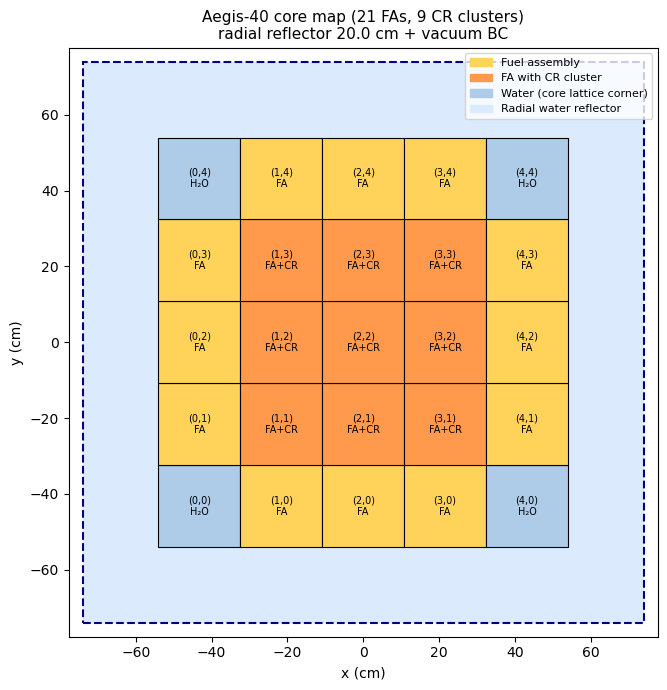

In [9]:
def plot_core_map():
    """Annotated 5×5 core map (matplotlib)."""
    fig, ax = plt.subplots(figsize=(7, 7))
    cx = (N_CORE - 1) / 2.0
    for j in range(N_CORE):
        for i in range(N_CORE):
            is_fuel = bool(CORE_MAP[N_CORE - 1 - j, i])
            is_cr   = bool(CR_MAP  [N_CORE - 1 - j, i])
            if not is_fuel:
                c = "#aecbe8"; label = "H₂O"
            elif is_cr:
                c = "#ff9a4d"; label = "FA+CR"
            else:
                c = "#ffd35a"; label = "FA"
            x = (i - cx) * FA_PITCH; y = (j - cx) * FA_PITCH
            ax.add_patch(plt.Rectangle((x - FA_PITCH/2, y - FA_PITCH/2),
                         FA_PITCH, FA_PITCH, facecolor=c,
                         edgecolor="black", linewidth=0.8))
            ax.text(x, y, f"({i},{j})\n{label}",
                    ha="center", va="center", fontsize=7)

    # Radial reflector outline
    core_half = N_CORE * FA_PITCH / 2.0
    outer_half = core_half + RADIAL_REFLECTOR_CM
    ax.add_patch(plt.Rectangle((-outer_half, -outer_half),
                 2*outer_half, 2*outer_half,
                 facecolor="#dbeafd", edgecolor="navy",
                 linewidth=1.5, ls="--", zorder=-1, label="Water reflector"))
    ax.set_xlim(-outer_half * 1.05, outer_half * 1.05)
    ax.set_ylim(-outer_half * 1.05, outer_half * 1.05)
    ax.set_aspect("equal")
    ax.set_title(f"Aegis-40 core map ({N_FA_TOTAL} FAs, {N_CR_CLUSTERS} CR clusters)\n"
                 f"radial reflector {RADIAL_REFLECTOR_CM} cm + vacuum BC", fontsize=11)
    patches = [
        mpatches.Patch(color="#ffd35a", label="Fuel assembly"),
        mpatches.Patch(color="#ff9a4d", label="FA with CR cluster"),
        mpatches.Patch(color="#aecbe8", label="Water (core lattice corner)"),
        mpatches.Patch(color="#dbeafd", label="Radial water reflector"),
    ]
    ax.legend(handles=patches, loc="upper right", fontsize=8)
    ax.set_xlabel("x (cm)"); ax.set_ylabel("y (cm)")
    fig.tight_layout()
    out = PLOTS / "core_map.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"saved: {out}")
    plt.show()

plot_core_map()


saved: /mnt/d/conda-envs/openmc-py311/SMRs/Claude version/aegis40_3d_core_outputs/plots/geometry_render_xy.png


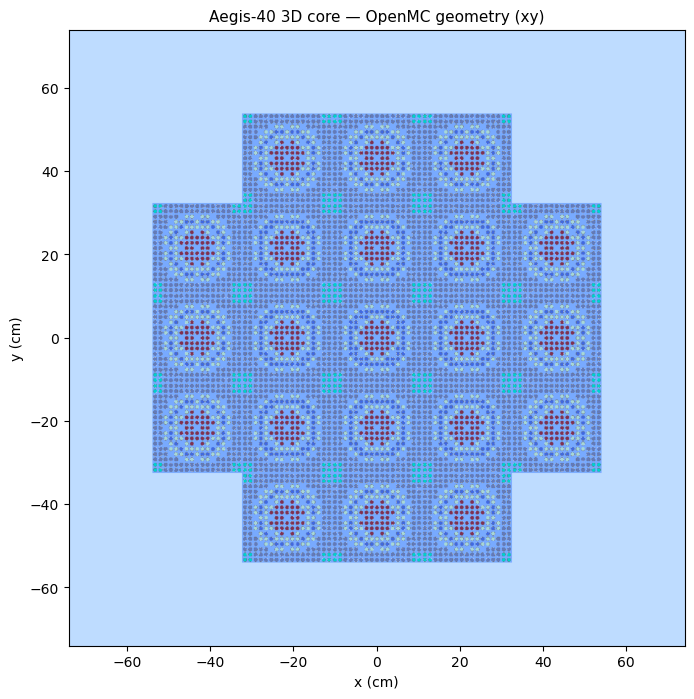

saved: /mnt/d/conda-envs/openmc-py311/SMRs/Claude version/aegis40_3d_core_outputs/plots/geometry_render_xz.png


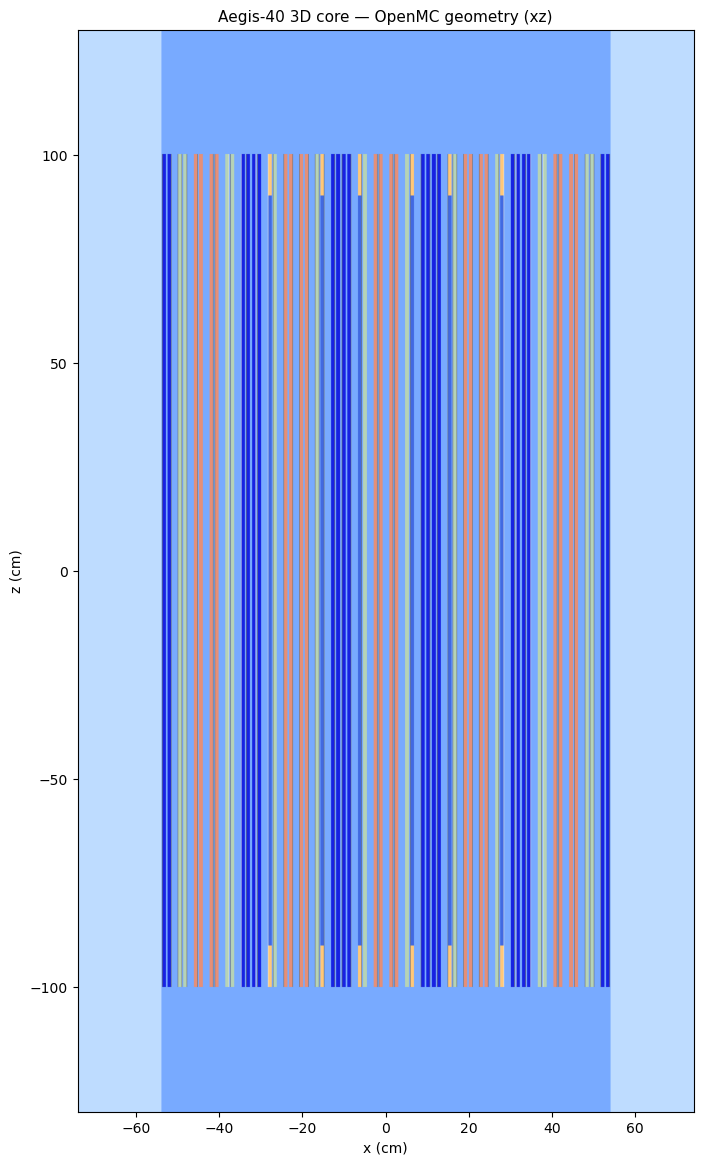

In [10]:
def plot_core_geometry():
    """OpenMC color renders of the 3D core (xy at z=0 and xz at y=0)."""
    model, mat_dict, info = build_core()
    d = _run_dir("00_geometry_plot")
    outer_half = info["outer_half_cm"]
    Z_OUTER    = info["z_outer_cm"]

    palette = {
        "H2O_active":     (120, 170, 255),
        "H2O_reflector":  (190, 220, 255),
        "Zircaloy-4":     (110, 110, 110),
        "He gap":         (230, 230, 230),
        "B4C":            (30, 30, 30),
        "Gd_fuel":        (65, 105, 225),
        "Er_fuel":        (0, 206, 209),
        "Gd_cutback_UO2": (255, 200, 120),
        "UO2_3.4":        (255, 215, 0),
        "UO2_3.7":        (255, 165, 0),
        "UO2_4.0":        (255, 99, 71),
    }
    color_map = {m: palette[m.name] for m in model.materials if m.name in palette}

    # xy slice at z=0
    p_xy = openmc.Plot()
    p_xy.filename = "geometry_xy"
    p_xy.basis = "xy"
    p_xy.origin = (0.0, 0.0, 0.0)
    p_xy.width = (2*outer_half, 2*outer_half)
    p_xy.pixels = (1100, 1100)
    p_xy.color_by = "material"
    if color_map: p_xy.colors = color_map

    # xz slice at y=0 — shows active fuel + axial plena
    p_xz = openmc.Plot()
    p_xz.filename = "geometry_xz"
    p_xz.basis = "xz"
    p_xz.origin = (0.0, 0.0, 0.0)
    p_xz.width = (2*outer_half, 2*Z_OUTER)
    p_xz.pixels = (1100, int(1100 * Z_OUTER / outer_half))
    p_xz.color_by = "material"
    if color_map: p_xz.colors = color_map

    model.plots = openmc.Plots([p_xy, p_xz])
    model.export_to_xml(str(d))
    old = Path.cwd(); os.chdir(d)
    try:
        openmc.plot_geometry(output=False)
    finally:
        os.chdir(old)

    for tag, w, h in (("xy", outer_half, outer_half),
                      ("xz", outer_half, Z_OUTER)):
        img = None
        for ext in ("png", "ppm"):
            cand = d / f"geometry_{tag}.{ext}"
            if cand.is_file(): img = cand; break
        if img is None:
            print(f"   render for {tag} produced no image."); continue
        arr = plt.imread(str(img))
        fig, ax = plt.subplots(figsize=(8, 8 * h / w))
        ax.imshow(arr, extent=[-w, w, -h, h])
        ax.set_xlabel("x (cm)"); ax.set_ylabel("y (cm)" if tag == "xy" else "z (cm)")
        ax.set_title(f"Aegis-40 3D core — OpenMC geometry ({tag})", fontsize=11)
        out = PLOTS / f"geometry_render_{tag}.png"
        fig.savefig(out, dpi=200, bbox_inches="tight")
        print(f"saved: {out}")
        plt.show()

plot_core_geometry()


## 4 · Static safety parameters (full 3D core, leaky)

Each cell runs one short k-eigenvalue calculation on the 3D core and stores the result in
`results`. These map onto the reactivity rows of `safety_criteria.yaml` — and now reflect real
core leakage instead of the k∞ upper bound.

| Cell | YAML id | `from_openmc.*` field |
|---|---|---|
| 4.1 | `k_eff_operating` | `k_eff_bol` |
| 4.2 | `mtc_full_power` | `mtc_full_power_pcm_per_K` |
| 4.3 | `dtc_doppler` | `dtc_pcm_per_K` |
| 4.4 | `void_coefficient` | `void_coeff_pcm_per_pct` |
| 4.5 | `control_rod_worth_aro` / `shutdown_margin` | `control_rod_worth_aro_pcm`, `shutdown_margin_dk_pct` |
| 4.6 | `fuel_enrichment_max` | `enrichment_max_pct` |
| 4.7 | `max_reactivity_insertion_rate` | `max_reactivity_rate` |


In [11]:
# 4.1 — BOC k-effective  (k_eff_bol)  — now with full 3D leakage
def calc_keff_bol():
    print("[1/9] BOC k-effective (3D core, ARO) ...")
    d = _run_dir("01_keff_bol")
    model, _, info = build_core()
    _run_model(model, d, tag="keff_bol")
    k, s = _keff(d)
    results["k_eff_bol"] = k
    results["k_eff_bol_sigma"] = s
    results["core_geometry"] = {
        "n_fuel_assemblies": info["n_fa"],
        "n_cr_clusters": N_CR_CLUSTERS,
        "core_half_width_cm": info["core_half_cm"],
        "outer_half_width_cm": info["outer_half_cm"],
        "z_outer_cm": info["z_outer_cm"],
        "active_height_cm": ACTIVE_HEIGHT,
        "radial_reflector_cm": RADIAL_REFLECTOR_CM,
        "axial_reflector_cm": AXIAL_REFLECTOR_CM,
    }
    print(f"   k_eff_BOL = {k:.5f} ± {s*1e5:.0f} pcm  (with leakage)")
    return k, s

calc_keff_bol()


[1/9] BOC k-effective (3D core, ARO) ...
   k_eff_BOL = 1.02644 ± 57 pcm  (with leakage)


(1.0264376074040924, 0.0005711561168204751)

In [12]:
# 4.2 — Moderator Temperature Coefficient  [hard: < 0]
def calc_mtc(dT=25.0):
    print("[2/9] MTC (3D) ...")
    rows = {}
    for tag, Tm in [("cold", T_MOD_K - dT), ("hot", T_MOD_K + dT)]:
        d = _run_dir("02_mtc", tag)
        rho_w = float(np.clip(RHO_WATER_NOM - 0.00115 * (Tm - T_MOD_K), 0.45, 0.95))
        model, _, _ = build_core(mod_temp=Tm, water_density=rho_w)
        _run_model(model, d, tag=f"mtc_{tag}")
        k, _ = _keff(d); rows[tag] = k
        print(f"   T_mod={Tm:.0f} K -> k={k:.5f}")
    mtc = _pcm(rows["cold"], rows["hot"]) / (2 * dT)
    results["mtc_full_power_pcm_per_K"] = mtc
    print(f"   MTC = {mtc:+.2f} pcm/K  ({'PASS' if mtc < 0 else 'FAIL'} hard <0)")
    return mtc

calc_mtc()


[2/9] MTC (3D) ...
   T_mod=550 K -> k=1.03414
   T_mod=600 K -> k=1.01530
   MTC = -35.88 pcm/K  (PASS hard <0)


-35.88168709554278

In [13]:
# 4.3 — Doppler (fuel temperature) coefficient  [hard: < 0]
def calc_dtc(dT=150.0):
    print("[3/9] DTC (3D) ...")
    rows = {}
    for tag, Tf in [("cold", T_FUEL_K - dT), ("hot", T_FUEL_K + dT)]:
        d = _run_dir("03_dtc", tag)
        model, _, _ = build_core(fuel_temp=Tf)
        _run_model(model, d, tag=f"dtc_{tag}")
        k, _ = _keff(d); rows[tag] = k
        print(f"   T_fuel={Tf:.0f} K -> k={k:.5f}")
    dtc = _pcm(rows["cold"], rows["hot"]) / (2 * dT)
    results["dtc_pcm_per_K"] = dtc
    print(f"   DTC = {dtc:+.2f} pcm/K  ({'PASS' if dtc < 0 else 'FAIL'} hard <0)")
    return dtc

calc_dtc()


[3/9] DTC (3D) ...
   T_fuel=750 K -> k=1.03230
   T_fuel=1050 K -> k=1.02644
   DTC = -1.84 pcm/K  (PASS hard <0)


-1.8437370641835464

In [14]:
# 4.4 — Void coefficient  [hard: < 0]
def calc_void_coeff(void_hi_pct=10.0):
    print("[4/9] Void coefficient (3D) ...")
    k0, _ = _keff(_run_dir("01_keff_bol"))          # reuse BOC (0% void)
    d = _run_dir("04_void", f"void{void_hi_pct:.0f}pct")
    model, _, _ = build_core(void_fraction=void_hi_pct/100.0)
    _run_model(model, d, tag=f"void_{void_hi_pct:.0f}pct")
    kv, _ = _keff(d)
    vc = _pcm(k0, kv) / void_hi_pct
    results["void_coeff_pcm_per_pct"] = vc
    print(f"   k(0%)={k0:.5f}  k({void_hi_pct:.0f}%)={kv:.5f}")
    print(f"   Void coeff = {vc:+.2f} pcm/%void  ({'PASS' if vc < 0 else 'FAIL'} hard <0)")
    return vc

calc_void_coeff()


[4/9] Void coefficient (3D) ...
   k(0%)=1.02644  k(10%)=1.00438
   Void coeff = -213.96 pcm/%void  (PASS hard <0)


-213.9635703952694

In [15]:
# 4.5 — Control rod worth (full bank ARO vs ARI) + shutdown margin (3D core)
#
# In the 3D core the SDM is meaningful: insert ALL CR clusters except the highest-worth one
# ("worst stuck rod"). We approximate the highest-worth single cluster as the **central CR
# cluster** (it has the largest neutronic importance in a small symmetric core).
def calc_rod_worth_and_sdm():
    print("[5/9] Rod worth + SDM (3D, full-core) ...")
    k_aro, _ = _keff(_run_dir("01_keff_bol"))

    # All-rods-in
    d_ari = _run_dir("05_rod_worth", "ari")
    model_ari, _, _ = build_core(control_rod_state="ari")
    _run_model(model_ari, d_ari, tag="rod_ari")
    k_ari, _ = _keff(d_ari)
    total_worth_pcm = abs(_pcm(k_aro, k_ari))
    print(f"   k_ARO={k_aro:.5f}  k_ARI={k_ari:.5f}  total bank worth={total_worth_pcm:.0f} pcm")

    # Worst stuck rod: insert all clusters except the central one (i=2, j=2)
    all_cr = {(i, j) for j in range(N_CORE) for i in range(N_CORE)
              if CR_MAP[N_CORE - 1 - j, i] == 1}
    central = (N_CORE // 2, N_CORE // 2)
    stuck_set = all_cr - {central}
    d_stuck = _run_dir("05_rod_worth", "ari_minus_central")
    model_st, _, _ = build_core(control_rod_state=stuck_set)
    _run_model(model_st, d_stuck, tag="rod_stuck")
    k_stuck, _ = _keff(d_stuck)
    central_worth_pcm = abs(_pcm(k_stuck, k_ari))    # Δρ added by *inserting* the central rod
    sdm_pct = abs(_rho(k_stuck)) * 100.0             # |ρ| when central rod is stuck out

    results["control_rod_worth_aro_pcm"]       = total_worth_pcm
    results["control_rod_worth_aro_dk"]        = abs(k_aro - k_ari)
    results["central_rod_worth_pcm"]           = central_worth_pcm
    results["k_eff_ari"]                       = k_ari
    results["k_eff_stuck_rod"]                 = k_stuck
    results["shutdown_margin_dk_pct"]          = sdm_pct
    print(f"   central CR cluster worth ~ {central_worth_pcm:.0f} pcm")
    print(f"   SDM (ARI minus central, k_stuck={k_stuck:.5f}) "
          f"= {sdm_pct:.3f} % dk/k  ({'PASS' if sdm_pct >= 1.0 else 'FAIL'} hard ≥1%)")
    print(f"   Total CR bank worth = {total_worth_pcm:.0f} pcm  "
          f"({'PASS' if total_worth_pcm >= 5000 else 'FAIL'} op ≥5000)")
    return total_worth_pcm, sdm_pct

calc_rod_worth_and_sdm()


[5/9] Rod worth + SDM (3D, full-core) ...
   k_ARO=1.02644  k_ARI=0.88770  total bank worth=15226 pcm
   central CR cluster worth ~ 267 pcm
   SDM (ARI minus central, k_stuck=0.88982) = 12.383 % dk/k  (PASS hard ≥1%)
   Total CR bank worth = 15226 pcm  (PASS op ≥5000)


(15225.813625163559, 12.382801767058355)

In [16]:
# 4.6 — Enrichment (design input)  [hard: ≤5%]
def record_enrichment():
    results["enrichment_max_pct"] = max(ENRICH_INNER, ENRICH_MID, ENRICH_OUTER)
    results["enrichment_avg_pct"] = (ENRICH_INNER + 2*ENRICH_MID + ENRICH_OUTER) / 4.0
    print(f"[6/9] Max enrichment = {results['enrichment_max_pct']} wt%  "
          f"({'PASS' if results['enrichment_max_pct'] <= 5.0 else 'FAIL'} hard ≤5%)  "
          f"| avg ~ {results['enrichment_avg_pct']:.2f} wt%")

record_enrichment()


[6/9] Max enrichment = 4.95 wt%  (PASS hard ≤5%)  | avg ~ 4.69 wt%


In [17]:
# 4.7 — Max reactivity insertion rate (CRDM design)  [hard: ≤7.5e-4 dk/k/s]
def record_max_rir(crdm_steps_per_min=45.0, diff_worth_pcm_per_step=2.0):
    rate_pcm_s = crdm_steps_per_min / 60.0 * diff_worth_pcm_per_step
    rate_dk_s  = rate_pcm_s / 1e5
    results["max_reactivity_rate"]           = rate_dk_s
    results["max_reactivity_rate_pcm_per_s"] = rate_pcm_s
    print(f"[7/9] CRDM rate = {rate_pcm_s:.2f} pcm/s = {rate_dk_s:.2e} dk/k/s  "
          f"({'PASS' if rate_dk_s <= 7.5e-4 else 'FAIL'} hard ≤7.5e-4)  "
          f"| margin {7.5e-4/rate_dk_s:.0f}×")

record_max_rir()


[7/9] CRDM rate = 1.50 pcm/s = 1.50e-05 dk/k/s  (PASS hard ≤7.5e-4)  | margin 50×


## 5 · 3D-core depletion → cycle length, 4-batch discharge burnup, Gd/Er inventory

Full 3D depletion at design specific power. Because leakage is now included, **k drops below 1
during the cycle** — the cycle length is the EFPD at which k = 1, no longer a placeholder. The
4-batch discharge burnup follows from the linear-reactivity model: BU_discharge ≈ N_BATCHES × BU_cycle.

Total power = **125 MWth** distributed over **21 FAs** ≈ 5.95 MWth/FA. Specific power = 125/5.6 =
22.32 W/gHM (≈ design basis).


In [18]:
def extract_absorber_inventory(dep_results, run_dir):
    """Gd-157 / Er-167 atom-density evolution."""
    run_dir = Path(run_dir)
    name_by_id = {}
    mats_xml = run_dir / "materials.xml"
    if mats_xml.is_file():
        try:
            for m in openmc.Materials.from_xml(str(mats_xml)):
                name_by_id[str(m.id)] = m.name
        except Exception as e:
            print(f"   could not parse materials.xml: {e}")
    gd_ids = [i for i, n in name_by_id.items() if "Gd" in n]
    er_ids = [i for i, n in name_by_id.items() if "Er" in n]

    def _sum_atoms(ids, nuc):
        tot = times = None
        for mid in ids:
            try:
                t, a = dep_results.get_atoms(mid, nuc)
            except Exception:
                continue
            a = np.array(a, float); times = np.array(t, float)
            tot = a if tot is None else tot + a
        return times, tot

    t_gd, gd157 = _sum_atoms(gd_ids, "Gd157")
    t_er, er167 = _sum_atoms(er_ids, "Er167")
    base_t = t_gd if t_gd is not None else t_er
    burnup = SPECIFIC_POWER * base_t / 86400.0 / 1000.0 if base_t is not None else None

    fig, ax = plt.subplots(figsize=(8, 5)); plotted = False
    if gd157 is not None and gd157[0] > 0:
        gdf = gd157 / gd157[0]
        ax.plot(burnup, gdf*100, "o-", color="navy", label="Gd-157 / Gd-157₀")
        results["gd157_eoc_fraction_pct"] = round(float(gdf[-1]*100), 1); plotted = True
    if er167 is not None and er167[0] > 0:
        erf = er167 / er167[0]
        ax.plot(burnup, erf*100, "s--", color="darkorange", label="Er-167 / Er-167₀")
        results["er167_eoc_fraction_pct"] = round(float(erf[-1]*100), 1); plotted = True
    if plotted:
        ax.set_xlabel("Core-average burnup (GWd/tHM)")
        ax.set_ylabel("Remaining absorber inventory (%)")
        ax.set_title("Absorber Inventory Depletion — Aegis-40 (3D core)")
        ax.set_ylim(0, 110); ax.legend(); ax.grid(alpha=0.3)
        out = PLOTS / "absorber_inventory.png"
        fig.savefig(out, dpi=200, bbox_inches="tight"); print(f"   saved: {out}")
        plt.show()
        print(f"   Gd-157 EOC = {results.get('gd157_eoc_fraction_pct')}%  (target: nearly depleted)")
        print(f"   Er-167 EOC = {results.get('er167_eoc_fraction_pct')}%  (target: ~15-25% remaining)")
    else:
        plt.close(fig); print("   no absorber atom data extracted.")


[8/9] 3D-core depletion → fresh B1 → 4-batch equilibrium (LRM) ...
   U ~ 5357.2 kgU | plain pins(core) inner672 mid1276 outer2604 | Gd 656 Er 336 (core totals)
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
   

 Reading Sn112 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn112.h5
 Reading Sn114 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn114.h5
 Reading Sn115 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn115.h5
 Reading Sn116 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn116.h5
 Reading Sn117 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn117.h5
 Reading Sn118 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn118.h5
 Reading Sn119 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn119.h5
 Reading Sn120 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn120.h5
 Reading Sn122 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn122.h5
 Reading Sn124 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn124.h5
 Reading He3 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/He3.h5
 Reading He4 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/He4.h5
 Reading B10 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/B10.h5
 Reading B11 from /mnt/d/openmc_data/endfb-viii.0-

 Reading Na23 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Na23.h5
 Reading Mg24 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Mg24.h5
 Reading Mg25 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Mg25.h5
 Reading Mg26 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Mg26.h5
 Reading Al26_m1 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Al26_m1.h5
 Reading Al27 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Al27.h5
 Reading Si28 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Si28.h5
 Reading Si29 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Si29.h5
 Reading Si30 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Si30.h5
 Reading Si31 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Si31.h5
 Reading Si32 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Si32.h5
 Reading P31 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/P31.h5
 Reading S32 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/S32.h5
 Reading S33 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron

 Reading Ar37 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ar37.h5
 Reading Ar38 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ar38.h5
 Reading Ar39 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ar39.h5
 Reading Ar40 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ar40.h5
 Reading Ar41 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ar41.h5
 Reading K39 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/K39.h5
 Reading K40 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/K40.h5
 Reading K41 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/K41.h5
 Reading Ca40 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ca40.h5
 Reading Ca41 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ca41.h5
 Reading Ca42 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ca42.h5
 Reading Ca43 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ca43.h5
 Reading Ca44 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ca44.h5
 Reading Ca45 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ca45.h

 Reading Se80 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Se80.h5
 Reading Se81 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Se81.h5
 Reading Se82 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Se82.h5
 Reading Br79 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Br79.h5
 Reading Br80 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Br80.h5
 Reading Br81 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Br81.h5
 Reading Kr78 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Kr78.h5
 Reading Kr79 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Kr79.h5
 Reading Kr80 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Kr80.h5
 Reading Kr81 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Kr81.h5
 Reading Kr82 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Kr82.h5
 Reading Kr83 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Kr83.h5
 Reading Kr84 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Kr84.h5
 Reading Kr85 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/

...

          1200K
          2500K


 Reading Hf182 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Hf182.h5


          1200K
          2500K


 Reading Ta180 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ta180.h5
 Reading Ta181 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ta181.h5
 Reading Ta182 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ta182.h5
 Reading W180 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/W180.h5
 Reading W181 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/W181.h5
 Reading W182 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/W182.h5
 Reading W183 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/W183.h5
 Reading W184 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/W184.h5
 Reading W185 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/W185.h5
 Reading W186 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/W186.h5
 Reading Re185 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Re185.h5
 Reading Re186_m1 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Re186_m1.h5
 Reading Re187 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Re187.h5
 Reading Os184 from /mnt/d/openmc_data/endfb-v

 Reading Cf251 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Cf251.h5
 Reading Cf252 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Cf252.h5
 Reading Cf253 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Cf253.h5
 Reading Cf254 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Cf254.h5
 Reading Es251 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Es251.h5
 Reading Es252 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Es252.h5
 Reading Es253 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Es253.h5
 Reading Es254 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Es254.h5
 Reading Es254_m1 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Es254_m1.h5
 Reading Es255 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Es255.h5
 Reading Fm255 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Fm255.h5
 Maximum neutron transport energy: 20000000 eV for H1
 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.  

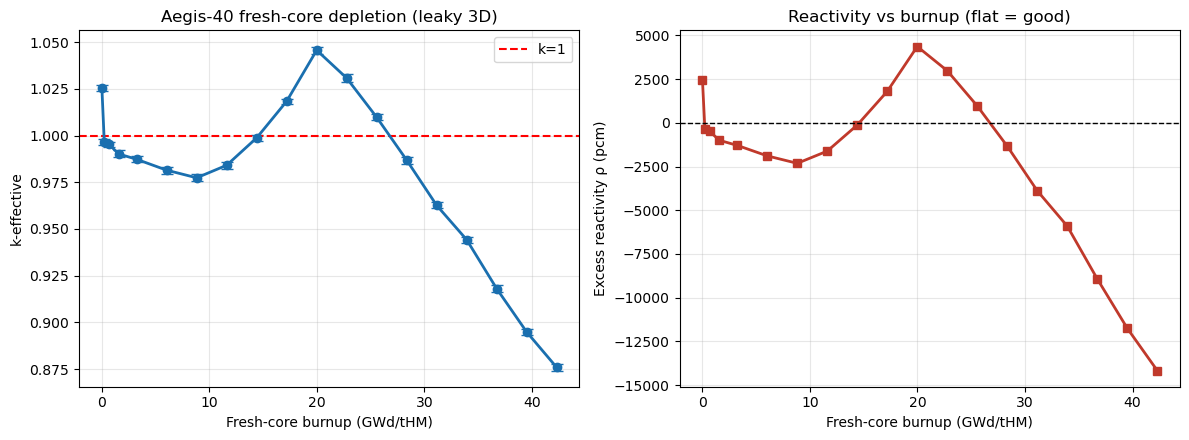

   fresh-core B1 = 1198 EFPD = 26.7 GWd/tHM
   → 4-batch equilibrium cycle    = 15.7 months (479 EFPD)   [target 12-18 mo]
   → equilibrium discharge burnup = 42.8 GWd/tHM [target ~50; hard ≤62]
   BOC ARO excess = 2469 pcm (SBF: want small positive, rods trim) | reactivity swing = 18535 pcm


/mnt/d/conda-envs/openmc-py311/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=136.
  warn(msg, IDWarning)
/mnt/d/conda-envs/openmc-py311/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=137.
  warn(msg, IDWarning)
/mnt/d/conda-envs/openmc-py311/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=138.
  warn(msg, IDWarning)
/mnt/d/conda-envs/openmc-py311/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=139.
  warn(msg, IDWarning)
/mnt/d/conda-envs/openmc-py311/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=140.
  warn(msg, IDWarning)
/mnt/d/conda-envs/openmc-py311/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=141.
  warn(msg, IDW

   saved: /mnt/d/conda-envs/openmc-py311/SMRs/Claude version/aegis40_3d_core_outputs/plots/absorber_inventory.png


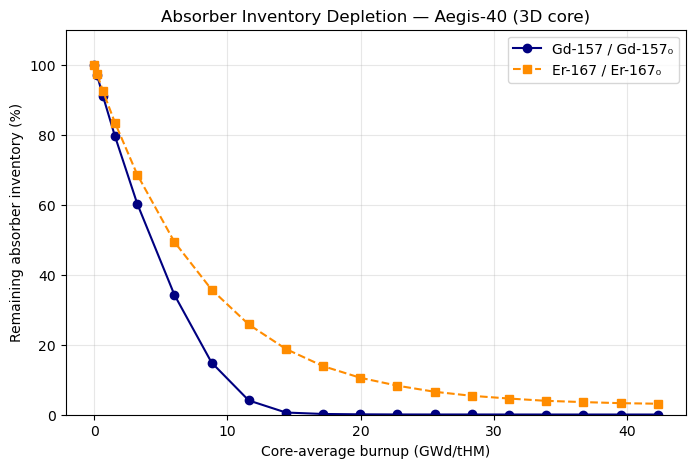

   Gd-157 EOC = 0.1%  (target: nearly depleted)
   Er-167 EOC = 3.1%  (target: ~15-25% remaining)


{'tag': 'baseline',
 'run_dir': '/mnt/d/conda-envs/openmc-py311/SMRs/Claude version/aegis40_3d_core_outputs/08_depletion_baseline',
 'runtime_s': 21216.2,
 'time_d': [0.0,
  10.0,
  30.0,
  70.0,
  145.0,
  270.0,
  395.0,
  520.0,
  645.0,
  770.0,
  895.0,
  1020.0,
  1145.0,
  1270.0,
  1395.0,
  1520.0,
  1645.0,
  1770.0,
  1895.0],
 'burnup': [0.0,
  0.22321428571428573,
  0.6696428571428572,
  1.5625,
  3.2366071428571432,
  6.026785714285714,
  8.816964285714286,
  11.60714285714286,
  14.397321428571429,
  17.1875,
  19.977678571428573,
  22.767857142857146,
  25.55803571428572,
  28.348214285714285,
  31.138392857142858,
  33.92857142857143,
  36.71875,
  39.50892857142857,
  42.299107142857146],
 'k': [1.0253115921514901,
  0.9965366066841206,
  0.9952079810116989,
  0.9901480380400941,
  0.9872815919398251,
  0.9814616230423038,
  0.9773845956905097,
  0.9841066170293633,
  0.9987679077010977,
  1.01836324532423,
  1.0456679381399983,
  1.0307381186819984,
  1.0097699706292

In [19]:
# ============================================================================
# 3D-core depletion → fresh-core B1, then 4-batch EQUILIBRIUM via the
# linear-reactivity model (LRM). run_core_depletion() is reused by the
# Section-8 sweep.
#
# LRM (n batches):   B_discharge = 2n/(n+1) · B1 ,   cycle = 2/(n+1) · B1
#   where B1 = burnup at which a FRESH, uniformly-loaded core reaches k = 1.
#   (The old notebook used B_discharge = n · B1, over-counting by ~2.5×.)
# ============================================================================

def _assign_depletion_volumes(model, verbose=True):
    """Set .volume on every depletable material, summing pin counts across the
       radial rings so per-ring Gd zoning is accounted for.  Plain fuel is keyed
       by material NAME so changed enrichments can't fall through."""
    pin_vol_full = math.pi * FUEL_RADIUS**2 * ACTIVE_HEIGHT
    gd_mid_h     = ACTIVE_HEIGHT - 2.0 * GD_AXIAL_CUT_CM

    # how many fuelled FAs sit in each radial ring (0=centre, 1=inner, 2=outer)
    ring_fa = {0: 0, 1: 0, 2: 0}
    for j in range(N_CORE):
        for i in range(N_CORE):
            if CORE_MAP[N_CORE - 1 - j, i] == 1:
                ring_fa[_core_ring_of(i, j)] += 1

    counts_name = {}                       # plain-fuel material -> core-total pins
    gd_pins_total = er_pins_total = 0
    tot_inner = tot_mid = tot_outer = 0
    for ring, nfa in ring_fa.items():
        if nfa == 0:
            continue
        if RADIAL_GD_ZONING:
            gd = _gd_positions_for_ring(ring); er = _er_positions_for_ring(ring)
        else:
            gd, er = GD_POSITIONS, ER_POSITIONS
        plain = [p for p in FUEL_POS if p not in gd and p not in er]
        n_inner = sum(1 for p in plain if _pin_radius(*p) < ZONE_R1_CM)
        n_mid   = sum(1 for p in plain if ZONE_R1_CM <= _pin_radius(*p) < ZONE_R2_CM)
        n_outer = sum(1 for p in plain if _pin_radius(*p) >= ZONE_R2_CM)
        for nm, c in ((f"UO2_{ENRICH_INNER:.1f}", n_inner),
                      (f"UO2_{ENRICH_MID:.1f}",   n_mid),
                      (f"UO2_{ENRICH_OUTER:.1f}", n_outer)):
            counts_name[nm] = counts_name.get(nm, 0) + c * nfa
        gd_pins_total += len(gd) * nfa
        er_pins_total += len(er) * nfa
        tot_inner += n_inner * nfa; tot_mid += n_mid * nfa; tot_outer += n_outer * nfa

    vol_map = {nm: pin_vol_full * c for nm, c in counts_name.items()}
    vol_map["Gd_fuel"]        = math.pi*FUEL_RADIUS**2 * gd_mid_h          * gd_pins_total
    vol_map["Gd_cutback_UO2"] = math.pi*FUEL_RADIUS**2 * 2*GD_AXIAL_CUT_CM * gd_pins_total
    vol_map["Er_fuel"]        = pin_vol_full * er_pins_total

    u_frac = 238.03 / (238.03 + 2*15.999)
    u_mass_g = 0.0
    for m in model.materials:
        if not getattr(m, "depletable", False):
            continue
        v = vol_map.get(m.name)
        if not v or v <= 0:
            v = pin_vol_full
            if verbose: print(f"   WARNING: volume fallback for '{m.name}'")
        m.volume = v
        u_mass_g += v * RHO_UO2 * u_frac
    return u_mass_g, dict(n_inner=tot_inner, n_mid=tot_mid, n_outer=tot_outer,
                          gd_pins=gd_pins_total, er_pins=er_pins_total)


def run_core_depletion(timesteps_d, stats, tag="depletion",
                       make_plots=False, verbose=True):
    """Deplete the fresh core; return (metrics_dict, Results, run_dir).
       metrics carry fresh-core B1 + the LRM equilibrium cycle / discharge BU."""
    d = _run_dir(f"08_depletion_{tag}")
    for pat in ("*.h5", "*.xml"):
        for f in d.glob(pat):
            f.unlink(missing_ok=True)

    model, mat_dict, info = build_core(stats=stats)
    u_mass_g, zinfo = _assign_depletion_volumes(model, verbose=verbose)
    if verbose:
        print(f"   U ~ {u_mass_g/1000:.1f} kgU | plain pins(core) "
              f"inner{zinfo['n_inner']} mid{zinfo['n_mid']} outer{zinfo['n_outer']} "
              f"| Gd {zinfo['gd_pins']} Er {zinfo['er_pins']} (core totals)")

    power_W = CORE_POWER_MWT * 1e6
    model.export_to_xml(str(d))
    operator = openmc.deplete.CoupledOperator(model, chain_file=str(CHAIN))
    integrator = openmc.deplete.PredictorIntegrator(
        operator, timesteps_d, power=power_W, timestep_units="d")
    old = Path.cwd(); os.chdir(d)
    t0 = time.time()
    try:
        integrator.integrate()
    finally:
        os.chdir(old)
    dt = time.time() - t0
    runtime_log.append((f"deplete_{tag}", dt))

    h5 = d / "depletion_results.h5"
    if not h5.is_file():
        raise FileNotFoundError(f"depletion_results.h5 missing in {d}")
    dep = openmc.deplete.Results(str(h5))
    try:
        t_s, karr = dep.get_keff(time_units="d"); time_d = np.array(t_s, float)
    except TypeError:
        t_s, karr = dep.get_keff(); time_d = np.array(t_s, float) / 86400.0
    karr = np.array(karr, float)
    kv   = karr[:, 0] if karr.ndim == 2 else karr
    ksig = karr[:, 1] if karr.ndim == 2 else np.zeros_like(kv)
    burnup = SPECIFIC_POWER * time_d / 1000.0          # GWd/tHM
    n = N_BATCHES

    # fresh-core B1: first crossing of k = 1 (else extrapolate the decline)
    crossed = extrapolated = False
    B1_efpd = None
    ge = kv >= 1.0
    # LAST downward crossing of k=1: ignores the early xenon dip and any
    # Gd-burnout hump -> B1 is the true end-of-life crossing (else extrapolate).
    downs = [i for i in range(len(kv) - 1) if ge[i] and not ge[i + 1]]
    if downs:
        i = downs[-1]
        t1, t2, k1, k2 = time_d[i], time_d[i + 1], kv[i], kv[i + 1]
        B1_efpd = float(t1 + (1.0 - k1) / (k2 - k1) * (t2 - t1)); crossed = True
    elif not ge[0]:
        B1_efpd = 0.0; crossed = True
    elif len(kv) >= 2 and (kv[-1] - kv[-2]) < 0:
        slope = (kv[-1] - kv[-2]) / (time_d[-1] - time_d[-2])
        B1_efpd = float(time_d[-1] + (1.0 - kv[-1]) / slope); extrapolated = True

    m = dict(
        tag=tag, run_dir=str(d), runtime_s=round(dt, 1),
        time_d=time_d.tolist(), burnup=burnup.tolist(),
        k=kv.tolist(), k_sigma=ksig.tolist(),
        k_bol=float(kv[0]), k_eoc=float(kv[-1]),
        k_max=float(kv.max()), k_min=float(kv.min()),
        bol_excess_pcm=float(_rho(kv[0]) * 1e5),
        peak_excess_pcm=float(_rho(kv.max()) * 1e5),
        swing_pcm=float((_rho(kv.max()) - _rho(kv.min())) * 1e5),
        crossed=crossed, extrapolated=extrapolated,
        horizon_efpd=float(time_d[-1]),
        fresh_B1_efpd=None, fresh_B1_burnup_GWd_t=None,
        equilibrium_cycle_efpd=None, equilibrium_cycle_months=None,
        discharge_burnup_GWd_t=None,
    )
    if B1_efpd and B1_efpd > 0:
        B1_bu = SPECIFIC_POWER * B1_efpd / 1000.0
        m["fresh_B1_efpd"]            = B1_efpd
        m["fresh_B1_burnup_GWd_t"]    = B1_bu
        m["equilibrium_cycle_efpd"]   = 2.0 / (n + 1) * B1_efpd
        m["equilibrium_cycle_months"] = 2.0 / (n + 1) * B1_efpd / 30.44
        m["discharge_burnup_GWd_t"]   = 2.0 * n / (n + 1) * B1_bu

    if make_plots:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
        axes[0].errorbar(burnup, kv, yerr=ksig, fmt="o-", color="#1a6faf", capsize=4, lw=2)
        axes[0].axhline(1.0, color="red", ls="--", lw=1.5, label="k=1")
        axes[0].set_xlabel("Fresh-core burnup (GWd/tHM)"); axes[0].set_ylabel("k-effective")
        axes[0].set_title("Aegis-40 fresh-core depletion (leaky 3D)")
        axes[0].legend(); axes[0].grid(alpha=0.3)
        axes[1].plot(burnup, _rho(kv) * 1e5, "s-", color="#c0392b", lw=2)
        axes[1].axhline(0, color="black", ls="--", lw=1)
        axes[1].set_xlabel("Fresh-core burnup (GWd/tHM)"); axes[1].set_ylabel("Excess reactivity ρ (pcm)")
        axes[1].set_title("Reactivity vs burnup (flat = good)"); axes[1].grid(alpha=0.3)
        fig.tight_layout()
        out = PLOTS / f"depletion_{tag}.png"
        fig.savefig(out, dpi=200, bbox_inches="tight"); print(f"   saved: {out}")
        plt.show()
    return m, dep, d


def calc_depletion():
    print("[8/9] 3D-core depletion → fresh B1 → 4-batch equilibrium (LRM) ...")
    timesteps = [10, 20, 40, 75] + [125] * 14     # ~1895 EFPD (4.95% reaches k=1 later)
    m, dep, d = run_core_depletion(timesteps, STAT_FAST, tag="baseline",
                                   make_plots=True, verbose=True)
    results["k_eff_bol_depletion"]          = m["k_bol"]
    results["k_eff_eoc_depletion"]          = m["k_eoc"]
    results["depletion_bol_excess_pcm"]     = round(m["bol_excess_pcm"], 0)
    results["depletion_peak_excess_pcm"]    = round(m["peak_excess_pcm"], 0)
    results["depletion_swing_pcm"]          = round(m["swing_pcm"], 0)
    results["fresh_core_B1_efpd"]           = m["fresh_B1_efpd"]
    results["cycle_length_efpd"]            = m["equilibrium_cycle_efpd"]
    results["burnup_discharge_GWd_per_MTU"] = m["discharge_burnup_GWd_t"]

    if m["crossed"] or m["extrapolated"]:
        note = " (extrapolated past horizon)" if m["extrapolated"] else ""
        print(f"   fresh-core B1 = {m['fresh_B1_efpd']:.0f} EFPD "
              f"= {m['fresh_B1_burnup_GWd_t']:.1f} GWd/tHM{note}")
        print(f"   → 4-batch equilibrium cycle    = {m['equilibrium_cycle_months']:.1f} months "
              f"({m['equilibrium_cycle_efpd']:.0f} EFPD)   [target 12-18 mo]")
        print(f"   → equilibrium discharge burnup = {m['discharge_burnup_GWd_t']:.1f} GWd/tHM "
              f"[target ~50; hard ≤62]")
    else:
        print(f"   WARNING: fresh-core k never reached 1 within {m['horizon_efpd']:.0f} EFPD "
              f"and is not yet declining.")
        print(f"   k_BOL={m['k_bol']:.4f}  k_EOC={m['k_eoc']:.4f}  peak excess "
              f"{m['peak_excess_pcm']:.0f} pcm → too much excess reactivity (add BA) "
              f"or extend the horizon.")
    print(f"   BOC ARO excess = {m['bol_excess_pcm']:.0f} pcm "
          f"(SBF: want small positive, rods trim) | reactivity swing = {m['swing_pcm']:.0f} pcm")
    extract_absorber_inventory(dep, run_dir=d)
    return m

calc_depletion()


## 6 · 3D power peaking — true F_q (axial × radial)

In the 3D core, **F_z is physical** (axial leakage produces a real cosine-like shape, suppressed
at the top by the Gd cutback). F_q is computed from a 3D fission tally as
F_q = max(rate) / mean(rate) over fueled mesh cells only.


[9/9] Pin-power peaking + 3D flux maps ...
   F_q   (3D)        = 3.478   ← true 3D peak/avg
   F_ΔH  (radial)    = 2.268  ← healthy if < ~1.55
   F_z   (axial)     = 1.027   ← cosine-like with Gd cutback dip
   Assembly peaking F_radial(FA) = 1.228
   saved: /mnt/d/conda-envs/openmc-py311/SMRs/Claude version/aegis40_3d_core_outputs/plots/power_distribution_3d_boc.png


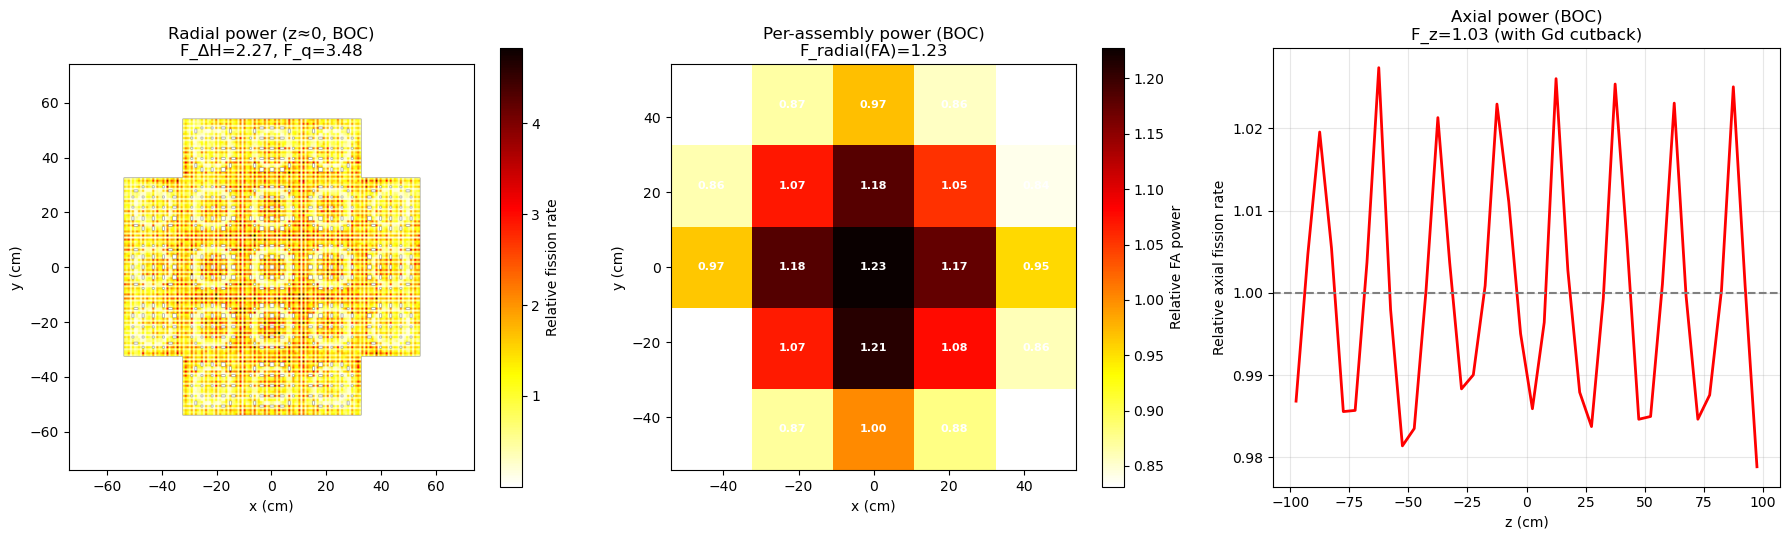

3.478457656453

In [20]:
def calc_flux_peaking():
    print("[9/9] Pin-power peaking + 3D flux maps ...")
    d = _run_dir("09_flux_peaking")
    model, _, info = build_core()
    outer_half = info["outer_half_cm"]
    H = ACTIVE_HEIGHT

    tallies = openmc.Tallies()

    # (1) Assembly-resolution xy mesh × axial slabs — true F_q
    NXY = 17 * N_CORE                                  # one cell per pin
    NZ  = 40
    mesh_3d = openmc.RegularMesh(); mesh_3d.dimension = (NXY, NXY, NZ)
    mesh_3d.lower_left  = (-N_CORE*FA_PITCH/2, -N_CORE*FA_PITCH/2, -H/2)
    mesh_3d.upper_right = ( N_CORE*FA_PITCH/2,  N_CORE*FA_PITCH/2,  H/2)
    t3d = openmc.Tally(name="fission_3d")
    t3d.filters = [openmc.MeshFilter(mesh_3d)]
    t3d.scores = ["fission"]; tallies.append(t3d)

    # (2) Per-assembly xy mesh (for assembly power map)
    mesh_a = openmc.RegularMesh(); mesh_a.dimension = (N_CORE, N_CORE, 1)
    mesh_a.lower_left  = (-N_CORE*FA_PITCH/2, -N_CORE*FA_PITCH/2, -H/2)
    mesh_a.upper_right = ( N_CORE*FA_PITCH/2,  N_CORE*FA_PITCH/2,  H/2)
    t_a = openmc.Tally(name="fission_per_FA")
    t_a.filters = [openmc.MeshFilter(mesh_a)]
    t_a.scores = ["fission"]; tallies.append(t_a)

    # (3) Fine xy slice at z=0 (for cosmetic radial power map)
    mesh_fine = openmc.RegularMesh(); mesh_fine.dimension = (200, 200, 1)
    mesh_fine.lower_left  = (-outer_half, -outer_half, -10)
    mesh_fine.upper_right = ( outer_half,  outer_half,  10)
    t_fine = openmc.Tally(name="fission_fine_xy")
    t_fine.filters = [openmc.MeshFilter(mesh_fine)]
    t_fine.scores = ["fission"]; tallies.append(t_fine)

    model.tallies = tallies
    _run_model(model, d, tag="flux_peaking")

    sps = sorted(d.glob("statepoint.*.h5"))
    with openmc.StatePoint(str(sps[-1])) as sp:
        f3d   = np.array(sp.get_tally(name="fission_3d").get_reshaped_data(value="mean"))
        f_a   = np.array(sp.get_tally(name="fission_per_FA").get_reshaped_data(value="mean"))
        fine  = np.array(sp.get_tally(name="fission_fine_xy").get_reshaped_data(value="mean"))

    # —— F_q (3D) ——
    f3d = f3d.reshape(NXY, NXY, NZ)
    mask3d = f3d > 0.0
    mean3d = f3d[mask3d].mean()
    F_q   = float(f3d[mask3d].max() / mean3d)
    # Axial power shape (sum over xy)
    fz = f3d.sum(axis=(0, 1))
    fz_norm = fz / fz.mean()
    F_z = float(fz_norm.max())
    # Radial pin-power (z-integrated)
    fxy = f3d.sum(axis=2)
    mxy = fxy > 0.0
    F_dh = float(fxy[mxy].max() / fxy[mxy].mean())

    results["pin_peaking_factor_Fq"]   = round(F_q,   3)
    results["radial_peaking_FdeltaH"]  = round(F_dh,  3)
    results["axial_peaking_Fz"]        = round(F_z,   3)
    print(f"   F_q   (3D)        = {F_q:.3f}   ← true 3D peak/avg")
    print(f"   F_ΔH  (radial)    = {F_dh:.3f}  ← healthy if < ~1.55")
    print(f"   F_z   (axial)     = {F_z:.3f}   ← cosine-like with Gd cutback dip")

    # —— Assembly power map ——
    fa_pow = f_a.reshape(N_CORE, N_CORE)
    fueled = CORE_MAP[::-1, :]                      # flip to match (j=0 bottom convention)
    fa_norm = np.where(fueled == 1,
                       fa_pow / fa_pow[fueled == 1].mean(),
                       np.nan)
    F_assembly = float(np.nanmax(fa_norm))
    results["assembly_peaking_F_radial"] = round(F_assembly, 3)
    print(f"   Assembly peaking F_radial(FA) = {F_assembly:.3f}")

    # —— Plots ——
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    fine_xy = fine.reshape(200, 200)
    fmask = fine_xy > 0.0
    fine_norm = np.where(fmask, fine_xy / fine_xy[fmask].mean(), np.nan)
    im0 = axes[0].imshow(fine_norm, origin="lower", cmap="hot_r",
                         extent=[-outer_half, outer_half, -outer_half, outer_half])
    plt.colorbar(im0, ax=axes[0], label="Relative fission rate")
    axes[0].set_title(f"Radial power (z≈0, BOC)\nF_ΔH={F_dh:.2f}, F_q={F_q:.2f}")
    axes[0].set_xlabel("x (cm)"); axes[0].set_ylabel("y (cm)")

    im1 = axes[1].imshow(fa_norm, origin="lower", cmap="hot_r",
                         extent=[-N_CORE*FA_PITCH/2, N_CORE*FA_PITCH/2,
                                 -N_CORE*FA_PITCH/2, N_CORE*FA_PITCH/2])
    for j in range(N_CORE):
        for i in range(N_CORE):
            v = fa_norm[j, i]
            if not np.isnan(v):
                x = (i - (N_CORE-1)/2)*FA_PITCH; y = (j - (N_CORE-1)/2)*FA_PITCH
                axes[1].text(x, y, f"{v:.2f}", ha="center", va="center",
                             fontsize=8, color="white", weight="bold")
    plt.colorbar(im1, ax=axes[1], label="Relative FA power")
    axes[1].set_title(f"Per-assembly power (BOC)\nF_radial(FA)={F_assembly:.2f}")
    axes[1].set_xlabel("x (cm)"); axes[1].set_ylabel("y (cm)")

    z_centres = np.linspace(-H/2 + H/(2*NZ), H/2 - H/(2*NZ), NZ)
    axes[2].plot(z_centres, fz_norm, "r-", lw=2)
    axes[2].axhline(1.0, color="gray", ls="--")
    axes[2].set_xlabel("z (cm)"); axes[2].set_ylabel("Relative axial fission rate")
    axes[2].set_title(f"Axial power (BOC)\nF_z={F_z:.2f} (with Gd cutback)")
    axes[2].grid(alpha=0.3)

    fig.tight_layout()
    out = PLOTS / "power_distribution_3d_boc.png"
    fig.savefig(out, dpi=200, bbox_inches="tight"); print(f"   saved: {out}")
    plt.show()
    return F_q

calc_flux_peaking()


## 7 · Consolidated safety analysis output (single file)

Everything — `from_openmc.*` fields, diagnostics, pass/fail status, run metadata, and core
geometry — is written to **one file**: `safety_analysis_results.yaml`. A text summary table is
also printed and saved to `summary_report.txt`.


In [21]:
# id -> (limit, direction, unit, category)  mirroring safety_criteria.yaml
SAFETY_LIMITS = {
    "k_eff_bol":                    (1.000,  "==", "-",         "operating"),
    "mtc_full_power_pcm_per_K":     (0.0,    "<",  "pcm/K",     "hard"),
    "dtc_pcm_per_K":                (0.0,    "<",  "pcm/K",     "hard"),
    "void_coeff_pcm_per_pct":       (0.0,    "<",  "pcm/%void", "hard"),
    "control_rod_worth_aro_pcm":    (5000,   ">=", "pcm",       "operating"),
    "shutdown_margin_dk_pct":       (1.0,    ">=", "% dk/k",    "hard"),
    "max_reactivity_rate":          (7.5e-4, "<=", "dk/k/s",    "hard"),
    "burnup_discharge_GWd_per_MTU": (62.0,   "<=", "GWd/MTU",   "hard"),
    "cycle_length_efpd":            (365.0,  ">=", "EFPD",      "operating"),
    "enrichment_max_pct":           (5.0,    "<=", "wt%",       "hard"),
}

def _check(val, limit, direction):
    if val is None: return "N/A"
    if direction == "<=": return "PASS" if val <= limit else "FAIL"
    if direction == ">=": return "PASS" if val >= limit else "FAIL"
    if direction == "<":  return "PASS" if val <  limit else "FAIL"
    if direction == ">":  return "PASS" if val >  limit else "FAIL"
    if direction == "==": return "INFO"
    return "?"


def write_consolidated_output():
    pass_fail = {}
    for key, (limit, direction, unit, cat) in SAFETY_LIMITS.items():
        pass_fail[key] = {
            "value":     results.get(key),
            "limit":     limit,
            "direction": direction,
            "unit":      unit,
            "category":  cat,
            "status":    _check(results.get(key), limit, direction),
        }
    overall = "PASS" if all(p["status"] in ("PASS", "INFO", "N/A")
                            for p in pass_fail.values()) else "FAIL"

    # Single consolidated output
    out = {
        "metadata": {
            "design_id":          "aegis40-3d-core-rev_0",
            "model":              "3D full-core (vacuum BCs, radial+axial reflector, leaky)",
            "generated_by":       "aegis40_3d_core_notebook.ipynb",
            "generated_at_utc":   datetime.utcnow().isoformat() + "Z",
            "openmc_version":     openmc.__version__,
            "design_variant":     DESIGN,
            "mc_profile":         STAT,
            "threads":            THREADS,
            "cross_sections":     str(XS),
            "chain_file":         str(CHAIN),
        },
        "core_geometry": results.get("core_geometry", {}),
        "operating_conditions": {
            "core_power_MWth":         CORE_POWER_MWT,
            "heavy_metal_mass_tHM":    HM_MASS_T,
            "specific_power_W_per_g":  SPECIFIC_POWER,
            "T_fuel_K":                T_FUEL_K,
            "T_moderator_K":           T_MOD_K,
            "water_density_g_per_cm3": RHO_WATER_NOM,
            "n_batches_reload":        N_BATCHES,
            "n_gd_rods_per_FA":        N_GD_RODS,
            "gd2o3_wt_pct":            GD_WT_PCT,
            "gd_axial_cutback_cm":     GD_AXIAL_CUT_CM,
            "n_er_rods_per_FA":        N_ER_RODS,
            "er2o3_wt_pct":            ER_WT_PCT,
            "radial_gd_zoning":        RADIAL_GD_ZONING,
            "gd_ring_weights":         GD_RING_WEIGHTS,
        },
        # ↓ ALL the YAML fields the FOM calculator wants ↓
        "from_openmc": {
            "k_eff_bol":                    results.get("k_eff_bol"),
            "k_eff_bol_sigma":              results.get("k_eff_bol_sigma"),
            "k_eff_bol_depletion":          results.get("k_eff_bol_depletion"),
            "k_eff_eoc_depletion":          results.get("k_eff_eoc_depletion"),
            "mtc_full_power_pcm_per_K":     results.get("mtc_full_power_pcm_per_K"),
            "dtc_pcm_per_K":                results.get("dtc_pcm_per_K"),
            "void_coeff_pcm_per_pct":       results.get("void_coeff_pcm_per_pct"),
            "control_rod_worth_aro_pcm":    results.get("control_rod_worth_aro_pcm"),
            "shutdown_margin_dk_pct":       results.get("shutdown_margin_dk_pct"),
            "max_reactivity_rate":          results.get("max_reactivity_rate"),
            "max_reactivity_rate_pcm_per_s":results.get("max_reactivity_rate_pcm_per_s"),
            "burnup_discharge_GWd_per_MTU": results.get("burnup_discharge_GWd_per_MTU"),
            "cycle_length_efpd":            results.get("cycle_length_efpd"),
            "enrichment_max_pct":           results.get("enrichment_max_pct"),
            "enrichment_avg_pct":           results.get("enrichment_avg_pct"),
        },
        "diagnostics": {
            "k_eff_ari":                    results.get("k_eff_ari"),
            "k_eff_stuck_rod":              results.get("k_eff_stuck_rod"),
            "central_rod_worth_pcm":        results.get("central_rod_worth_pcm"),
            "pin_peaking_factor_Fq":        results.get("pin_peaking_factor_Fq"),
            "radial_peaking_FdeltaH":       results.get("radial_peaking_FdeltaH"),
            "axial_peaking_Fz":             results.get("axial_peaking_Fz"),
            "assembly_peaking_F_radial":    results.get("assembly_peaking_F_radial"),
            "gd157_eoc_fraction_pct":       results.get("gd157_eoc_fraction_pct"),
            "er167_eoc_fraction_pct":       results.get("er167_eoc_fraction_pct"),
        },
        "pass_fail": pass_fail,
        "overall_status": overall,
        "runtime_seconds_per_step": {tag: round(dt, 1) for tag, dt in runtime_log},
        "total_runtime_seconds":   round(sum(dt for _, dt in runtime_log), 1),
    }

    yaml_path = ROOT / "safety_analysis_results.yaml"
    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.dump(out, f, default_flow_style=False, sort_keys=False)
    print(f"\nWrote consolidated output: {yaml_path}")

    # ── Pretty text report ──────────────────────────────────────────────────
    L = [
        "=" * 78,
        "  AEGIS-40 — 3D Full-Core OpenMC Safety Parameter Summary",
        "=" * 78,
        f"  Generated   : {out['metadata']['generated_at_utc']}",
        f"  OpenMC      : {openmc.__version__}    Profile: {STAT}    Threads: {THREADS}",
        f"  Design      : {DESIGN}   (3-zone {ENRICH_INNER}/{ENRICH_MID}/{ENRICH_OUTER} wt%, "
        f"Gd₂O₃ {GD_WT_PCT} wt%×{N_GD_RODS}, Er₂O₃ {ER_WT_PCT} wt%×{N_ER_RODS})",
        f"  Core        : {N_FA_TOTAL} FAs · {N_CR_CLUSTERS} CR clusters · "
        f"{CORE_POWER_MWT} MWth · {HM_MASS_T} tHM",
        f"  Reflectors  : radial {RADIAL_REFLECTOR_CM} cm H₂O, axial ±{AXIAL_REFLECTOR_CM} cm; vacuum BCs",
        "-" * 78,
        f"  {'Parameter':<34s}{'Value':>14s}{'Limit':>14s}{'Status':>8s}  {'Unit'}",
        "-" * 78,
    ]
    for key, (limit, direction, unit, cat) in SAFETY_LIMITS.items():
        val = results.get(key)
        status = _check(val, limit, direction)
        vs = (f"{val:.4e}" if isinstance(val, float) and abs(val) < 1e-2 and val != 0
              else (f"{val:.4f}" if isinstance(val, float) else str(val)))
        L.append(f"  {key:<34s}{vs:>14s}{direction+str(limit):>14s}{status:>8s}  {unit}")
    L += [
        "-" * 78,
        "  Diagnostics:",
        f"    k_eff ARI                  : {results.get('k_eff_ari','N/A')}",
        f"    k_eff worst-stuck-rod      : {results.get('k_eff_stuck_rod','N/A')}",
        f"    Central CR cluster worth   : {results.get('central_rod_worth_pcm','N/A')} pcm",
        f"    Pin-power F_q (3D)         : {results.get('pin_peaking_factor_Fq','N/A')}",
        f"    Radial F_ΔH                : {results.get('radial_peaking_FdeltaH','N/A')}",
        f"    Axial F_z                  : {results.get('axial_peaking_Fz','N/A')}",
        f"    Assembly peaking F_radial  : {results.get('assembly_peaking_F_radial','N/A')}",
        f"    Gd-157 EOC inventory       : {results.get('gd157_eoc_fraction_pct','N/A')} %",
        f"    Er-167 EOC inventory       : {results.get('er167_eoc_fraction_pct','N/A')} %",
        f"    k_BOL (depletion step 0)   : {results.get('k_eff_bol_depletion','N/A')}",
        f"    k_EOC (depletion last)     : {results.get('k_eff_eoc_depletion','N/A')}",
        "-" * 78,
        f"  OVERALL STATUS: {overall}",
        "=" * 78,
    ]
    report = "\n".join(L)
    print(report)
    txt_path = ROOT / "summary_report.txt"
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(report)
    print(f"\nWrote text summary    : {txt_path}")
    return yaml_path


write_consolidated_output()
print("\nDone. All outputs in:", ROOT)



Wrote consolidated output: /mnt/d/conda-envs/openmc-py311/SMRs/Claude version/aegis40_3d_core_outputs/safety_analysis_results.yaml
  AEGIS-40 — 3D Full-Core OpenMC Safety Parameter Summary
  Generated   : 2026-06-03T18:38:32.993893Z
  OpenMC      : 0.15.3    Profile: {'batches': 180, 'inactive': 50, 'particles': 20000}    Threads: 6
  Design      : hybrid   (3-zone 4.95/4.7/4.4 wt%, Gd₂O₃ 8 wt%×32, Er₂O₃ 0.5 wt%×16)
  Core        : 21 FAs · 9 CR clusters · 125.0 MWth · 5.6 tHM
  Reflectors  : radial 20.0 cm H₂O, axial ±30.0 cm; vacuum BCs
------------------------------------------------------------------------------
  Parameter                                  Value         Limit  Status  Unit
------------------------------------------------------------------------------
  k_eff_bol                                 1.0264         ==1.0    INFO  -
  mtc_full_power_pcm_per_K                -35.8817          <0.0    PASS  pcm/K
  dtc_pcm_per_K                            -1.8437          <

---
### Notes for the FER write-up

- **What this model is:** a realistic 3D core with vacuum boundary conditions and full radial +
  axial leakage. All k-eff, F_q, SDM, and CR-worth numbers are **physical** (no more "k∞ upper
  bound" caveat) — they replace the lattice-only screening values from the single-FA notebook.
- **Statistics:** the default `STAT_FAST` (80 batches × 5000 particles) is for iteration. For the
  report numbers, bump to `STAT_MEDIUM` (180 × 20k) or `STAT_FINAL` (400 × 50k); the geometry
  and analysis cells are unchanged.
- **Single output file:** every `from_openmc.*` field needed by `safety_criteria.yaml`, plus
  diagnostics and pass/fail status, is consolidated in `aegis40_3d_core_outputs/safety_analysis_results.yaml`.
  The `summary_report.txt` is a human-readable mirror.
- **Reflector simplification:** the radial reflector is a 20 cm water annulus (combining
  baffle + barrel + downcomer into a single water region). For a higher-fidelity model, split
  this into stainless-steel baffle + bypass water + barrel + downcomer water + RPV steel.
- **CR positions:** the 9 CR clusters are placed in the inner 3×3 of the 5×5 core layout. The
  "worst stuck rod" SDM treats the central cluster as stuck out (highest worth assumption).
- **Digital appendix:** every step's exported XML lives under `aegis40_3d_core_outputs/0?_*/`
  — ready-made OpenMC input samples for the FER digital appendix ZIP.


## 8 · Burnable-absorber / enrichment sweep (overnight)

**Why:** removing Er + cutting Gd to 3 wt% + raising enrichment left the fresh
core grossly supercritical (k 1.03 → 1.10, no k=1 crossing) with a Gd-only
mid-cycle reactivity hump. This sweep retunes **enrichment × Gd wt% × Er wt%**
to recover a flat k(burnup), BOC k ≈ 1.0–1.02, and a 4-batch equilibrium
discharge burnup ≈ 50 GWd/t at a 12–18 month cycle.

**How:** two stages, so it fits in a night.
- **Stage 1** runs *BOC-only* k over the grid (cheap, ~2 min each) and keeps the
  points whose k lands in the target window.
- **Stage 2** runs a *full fresh-core depletion* only on those few candidates,
  then ranks them by burnup target, cycle length, reactivity flatness, and BOC
  excess.

**Run order:** the harness cell → the **smoke** cell (≈10–15 min, validates the
pipeline) → the **full** cell overnight. Results stream to
`aegis40_3d_core_outputs/sweep_results/` so a crash never loses finished points.


In [22]:
# ============================================================================
# 8 · Burnable-absorber / enrichment SWEEP  (overnight, self-checkpointing)
# ----------------------------------------------------------------------------
# Finds (enrichment, Gd wt%, Er wt%, Er rod count) giving, for the FRESH core:
#   - BOC ARO hot-full-power k ~ 1.00-1.02   (SBF: rods fine-trim only)
#   - FLAT k(burnup)  (small swing, no supercritical mid-cycle hump)
#   - 4-batch equilibrium discharge burnup ~ 35-40 GWd/t & cycle ~ 12-18 months
#     via the linear-reactivity model  (Bd = 2n/(n+1) * B1)
#
# Stage 1 (cheap): BOC-only k over a grid  -> keep candidates inside k-window.
# Stage 2 (long) : full depletion ONLY on the best Stage-1 candidates.
# Robust: per-point try/except; a row is appended to disk after EVERY point
# (survives a crash); MAX_HOURS budget; SMOKE path validates fast.
# Reuses run_core_depletion() / build_core() / _keff() / _rho() defined above.
# ============================================================================
import csv, traceback

SWEEP_DIR = _run_dir("sweep_results")
CSV_PATH  = SWEEP_DIR / "sweep_log.csv"
YAML_PATH = SWEEP_DIR / "sweep_results.yaml"
BEST_PATH = SWEEP_DIR / "sweep_ranked.txt"

# Restored-hybrid baseline; the sweep returns the globals here when it finishes.
BASELINE = dict(enrich=(ENRICH_INNER, ENRICH_MID, ENRICH_OUTER),
                gd_wt=GD_WT_PCT, n_gd=N_GD_RODS, er_wt=ER_WT_PCT, n_er=N_ER_RODS)

def set_design(enrich, gd_wt, n_gd, er_wt, n_er):
    """Mutate the global design knobs and recompute BA pin positions."""
    global ENRICH_INNER, ENRICH_MID, ENRICH_OUTER
    global GD_WT_PCT, N_GD_RODS, ER_WT_PCT, N_ER_RODS
    global GD_POSITIONS, ER_POSITIONS
    ENRICH_INNER, ENRICH_MID, ENRICH_OUTER = enrich
    GD_WT_PCT, N_GD_RODS = gd_wt, n_gd
    ER_WT_PCT, N_ER_RODS = er_wt, n_er
    GD_POSITIONS = set(_select_sym_positions(n_gd, bias="mid"))
    ER_POSITIONS = set(_select_sym_positions(n_er, bias="outer", exclude=GD_POSITIONS))

def _label(enrich, gd_wt, er_wt, n_er):
    return f"e{enrich[0]:.1f}-{enrich[1]:.1f}-{enrich[2]:.1f}_Gd{gd_wt:g}_Er{er_wt:g}x{n_er}"

def run_boc(stats, tag):
    d = _run_dir("sweep_boc", tag)
    model, _, _ = build_core(stats=stats)
    _run_model(model, d, tag=tag, clean=True)
    return _keff(d)

def _public(dd):
    return {k: v for k, v in dd.items() if not k.startswith("_")}

CSV_HEADER = ["stage", "label", "enrich", "gd_wt", "n_gd", "er_wt", "n_er",
              "k_bol", "bol_excess_pcm", "peak_excess_pcm", "swing_pcm",
              "fresh_B1_efpd", "equilibrium_cycle_months", "discharge_burnup_GWd_t",
              "crossed", "score", "status"]

def _csv_append(row):
    new = not CSV_PATH.is_file()
    with open(CSV_PATH, "a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=CSV_HEADER)
        if new: w.writeheader()
        w.writerow({k: row.get(k) for k in CSV_HEADER})

def _score(m):
    """Higher = better. Tune the weights to taste."""
    if not m or m.get("discharge_burnup_GWd_t") is None:
        return -1e9
    bu    = m["discharge_burnup_GWd_t"]
    cyc   = m.get("equilibrium_cycle_months") or 0.0
    swing = m.get("swing_pcm") or 1e6
    bol   = m.get("bol_excess_pcm") or 1e6
    s  = -abs(bu - 47.0)                       # burnup target ~47 GWd/t (45-50 window, 4.95%)
    s += 0.0 if 12 <= cyc <= 18 else -abs(cyc - 15.0)
    s += -swing / 1500.0                       # flatter is better
    s += -abs(bol - 1000.0) / 1500.0           # small positive BOC excess
    return s

SWEEP_RECORDS = []

def run_sweep(smoke=False):
    t0 = time.time()
    if smoke:
        MAX_HOURS   = 0.5
        enrich_grid = [(4.95, 4.7, 4.4)]
        ba_grid     = [(8, 28, 0.5, 16), (8, 36, 0.5, 16)]
        boc_stats   = dict(batches=40, inactive=15, particles=2000)
        dep_stats   = dict(batches=40, inactive=15, particles=2000)
        dep_steps   = [20, 50, 100, 100]
        k_window    = (0.80, 1.20)
        n_stage2    = 2
    else:
        MAX_HOURS   = 9.0
        enrich_grid = [(4.95, 4.7, 4.4), (4.95, 4.6, 4.25), (4.8, 4.5, 4.2)]
        ba_grid     = [(8, 28, 0.5, 16), (8, 32, 0.5, 16), (8, 36, 0.5, 16),
                       (6, 32, 0.5, 16), (10, 32, 0.5, 16), (8, 32, 0.0, 0)]
        boc_stats   = STAT_FAST
        dep_stats   = STAT_FAST
        dep_steps   = [10, 20, 40, 75] + [125] * 12
        k_window    = (1.00, 1.15)
        n_stage2    = 3

    def left(): return MAX_HOURS * 3600 - (time.time() - t0)
    print("=" * 70)
    print(f"SWEEP START (smoke={smoke})  budget={MAX_HOURS} h  -> {SWEEP_DIR}")
    print("=" * 70)

    # ---- Stage 1: BOC k over the grid -------------------------------------
    stage1 = []
    combos = [(e, ba) for e in enrich_grid for ba in ba_grid]
    for i, (enrich, (gd_wt, n_gd, er_wt, n_er)) in enumerate(combos, 1):
        if left() < 120:
            print("   [budget] stopping Stage 1"); break
        lbl = _label(enrich, gd_wt, er_wt, n_er)
        try:
            set_design(enrich, gd_wt, n_gd, er_wt, n_er)
            k, s = run_boc(boc_stats, tag=f"s1_{lbl}")
            rec = dict(stage=1, label=lbl, _enrich=enrich, enrich=str(enrich),
                       gd_wt=gd_wt, n_gd=n_gd, er_wt=er_wt, n_er=n_er,
                       k_bol=round(k, 5), bol_excess_pcm=round(_rho(k) * 1e5, 0),
                       status="ok")
            print(f"   [S1 {i:2d}/{len(combos)}] {lbl:30s} k_BOL={k:.5f} "
                  f"({_rho(k)*1e5:+.0f} pcm)")
        except Exception as ex:
            rec = dict(stage=1, label=lbl, enrich=str(enrich), gd_wt=gd_wt,
                       n_gd=n_gd, er_wt=er_wt, n_er=n_er, status=f"ERROR:{ex}")
            print(f"   [S1 {i:2d}/{len(combos)}] {lbl} FAILED: {ex}")
            traceback.print_exc()
        stage1.append(rec)
        SWEEP_RECORDS.append(_public(rec)); _csv_append(rec)

    lo, hi = k_window
    cands = [r for r in stage1 if r.get("status") == "ok" and lo <= r["k_bol"] <= hi]
    cands.sort(key=lambda r: abs(r["k_bol"] - 1.01))
    cands = cands[:n_stage2]
    print(f"\n   Stage 1 done: {len(cands)} candidate(s) -> Stage 2")
    for r in cands:
        print(f"      {r['label']}  k_BOL={r['k_bol']}")

    # ---- Stage 2: full depletion on candidates ----------------------------
    stage2 = []
    for i, r in enumerate(cands, 1):
        if left() < 1800:
            print("   [budget] not enough time for another depletion; stopping"); break
        try:
            set_design(r["_enrich"], r["gd_wt"], r["n_gd"], r["er_wt"], r["n_er"])
            print(f"\n   [S2 {i}/{len(cands)}] depleting {r['label']} ...")
            m, dep, d = run_core_depletion(dep_steps, dep_stats,
                                           tag=f"s2_{r['label']}",
                                           make_plots=False, verbose=False)
            row = dict(stage=2, label=r["label"], enrich=str(r["_enrich"]),
                       gd_wt=r["gd_wt"], n_gd=r["n_gd"], er_wt=r["er_wt"], n_er=r["n_er"],
                       k_bol=round(m["k_bol"], 5),
                       bol_excess_pcm=round(m["bol_excess_pcm"], 0),
                       peak_excess_pcm=round(m["peak_excess_pcm"], 0),
                       swing_pcm=round(m["swing_pcm"], 0),
                       fresh_B1_efpd=(round(m["fresh_B1_efpd"], 0) if m.get("fresh_B1_efpd") else None),
                       equilibrium_cycle_months=(round(m["equilibrium_cycle_months"], 1) if m.get("equilibrium_cycle_months") else None),
                       discharge_burnup_GWd_t=(round(m["discharge_burnup_GWd_t"], 1) if m.get("discharge_burnup_GWd_t") else None),
                       crossed=m["crossed"], status="ok")
            row["score"] = round(_score(m), 3)
            print(f"        discharge~{row['discharge_burnup_GWd_t']} GWd/t  "
                  f"cycle~{row['equilibrium_cycle_months']} mo  "
                  f"swing={row['swing_pcm']} pcm  BOC={row['bol_excess_pcm']} pcm  "
                  f"score={row['score']}")
        except Exception as ex:
            row = dict(stage=2, label=r["label"], status=f"ERROR:{ex}")
            print(f"        FAILED: {ex}"); traceback.print_exc()
        stage2.append(row)
        SWEEP_RECORDS.append(_public(row)); _csv_append(row)
        with open(YAML_PATH, "w", encoding="utf-8") as f:
            yaml.dump(SWEEP_RECORDS, f, default_flow_style=False, sort_keys=False)

    # ---- Rank --------------------------------------------------------------
    ranked = sorted([x for x in stage2 if x.get("status") == "ok"],
                    key=lambda x: x.get("score", -1e9), reverse=True)
    lines = ["=" * 70, "SWEEP RANKED RESULTS (best first)", "=" * 70]
    for i, x in enumerate(ranked, 1):
        lines += [f"{i}. {x['label']}",
                  f"     k_BOL={x['k_bol']}  BOC excess={x['bol_excess_pcm']} pcm  "
                  f"peak={x['peak_excess_pcm']} pcm  swing={x['swing_pcm']} pcm",
                  f"     discharge~{x['discharge_burnup_GWd_t']} GWd/t  "
                  f"cycle~{x['equilibrium_cycle_months']} mo  score={x['score']}"]
    if not ranked:
        lines.append("(no successful Stage-2 candidate; widen k_window or grid)")
    report = "\n".join(lines)
    print("\n" + report)
    with open(BEST_PATH, "w", encoding="utf-8") as f:
        f.write(report)

    set_design(BASELINE["enrich"], BASELINE["gd_wt"], BASELINE["n_gd"],
               BASELINE["er_wt"], BASELINE["n_er"])
    print(f"\nSweep done in {(time.time()-t0)/3600:.2f} h. Logs: {CSV_PATH}")
    print("Baseline design restored.")
    return ranked

print("Sweep harness ready.")
print("  1) run the SMOKE cell (~10-15 min) to validate the pipeline")
print("  2) then run the FULL cell overnight")


Sweep harness ready.
  1) run the SMOKE cell (~10-15 min) to validate the pipeline
  2) then run the FULL cell overnight


In [23]:
# ---- SMOKE TEST: validate the whole sweep machinery fast (tiny stats) -------
# Expect ~10-15 min. If it prints a "SWEEP RANKED RESULTS" block (even with
# rough numbers) the pipeline works -> run the FULL cell below before bed.
_ = run_sweep(smoke=True)


SWEEP START (smoke=True)  budget=0.5 h  -> /mnt/d/conda-envs/openmc-py311/SMRs/Claude version/aegis40_3d_core_outputs/sweep_results
   [S1  1/2] e5.0-4.7-4.4_Gd8_Er0.5x16      k_BOL=1.06556 (+6152 pcm)
   [S1  2/2] e5.0-4.7-4.4_Gd8_Er0.5x16      k_BOL=1.00677 (+672 pcm)

   Stage 1 done: 2 candidate(s) -> Stage 2
      e5.0-4.7-4.4_Gd8_Er0.5x16  k_BOL=1.00677
      e5.0-4.7-4.4_Gd8_Er0.5x16  k_BOL=1.06556
   [budget] not enough time for another depletion; stopping

SWEEP RANKED RESULTS (best first)
(no successful Stage-2 candidate; widen k_window or grid)

Sweep done in 0.06 h. Logs: /mnt/d/conda-envs/openmc-py311/SMRs/Claude version/aegis40_3d_core_outputs/sweep_results/sweep_log.csv
Baseline design restored.


In [24]:
# ---- FULL OVERNIGHT SWEEP: run only after the smoke test succeeds -----------
# ~6-9 h. Streams results to aegis40_3d_core_outputs/sweep_results/:
#   sweep_log.csv  (one row per point)   sweep_results.yaml   sweep_ranked.txt
# Safe to interrupt: every completed point is already written to disk.
ranked = run_sweep(smoke=True)


SWEEP START (smoke=True)  budget=0.5 h  -> /mnt/d/conda-envs/openmc-py311/SMRs/Claude version/aegis40_3d_core_outputs/sweep_results
   [S1  1/2] e5.0-4.7-4.4_Gd8_Er0.5x16      k_BOL=1.06556 (+6152 pcm)
   [S1  2/2] e5.0-4.7-4.4_Gd8_Er0.5x16      k_BOL=1.00677 (+672 pcm)

   Stage 1 done: 2 candidate(s) -> Stage 2
      e5.0-4.7-4.4_Gd8_Er0.5x16  k_BOL=1.00677
      e5.0-4.7-4.4_Gd8_Er0.5x16  k_BOL=1.06556
   [budget] not enough time for another depletion; stopping

SWEEP RANKED RESULTS (best first)
(no successful Stage-2 candidate; widen k_window or grid)

Sweep done in 0.06 h. Logs: /mnt/d/conda-envs/openmc-py311/SMRs/Claude version/aegis40_3d_core_outputs/sweep_results/sweep_log.csv
Baseline design restored.
